# 🏥 NHS Patient Satisfaction — Sentiment Analysis
**Module:** 7150CEM Data Science Project  
**Student:** Uday Kiran Pappu  
**Supervisor:** Dr. Omid Chatrabgoun  

---

## Project Pipeline
| Stage | Description |
|-------|-------------|
| 1 | Data Collection & Loading |
| 2 | Data Cleaning & NLP Preprocessing |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Extraction (TF-IDF) |
| 5 | Sentiment Classification (VADER, TextBlob, ML) |
| 6 | Trend Analysis & Topic Modelling (LDA) |
| 7 | Final Dashboard & Summary |

---

In [1]:
# ============================================================
# CELL 1: Install & Import All Dependencies
# ============================================================
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'wordcloud', 'textblob', 'vaderSentiment', '--quiet'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import re, string, warnings, os
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings('ignore')

for pkg in ['punkt','punkt_tab','stopwords','wordnet',
            'averaged_perceptron_tagger','vader_lexicon']:
    nltk.download(pkg, quiet=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'positive': '#2ecc71',
    'negative': '#e74c3c',
    'neutral':  '#3498db',
    'primary':  '#2c3e50',
    'accent':   '#9b59b6',
}

OUTPUT_DIR = '/kaggle/working' if os.path.exists('/kaggle/working') else '.'
print('✅ All dependencies loaded successfully.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00
✅ All dependencies loaded successfully.


In [2]:
# ============================================================
# STAGE 1: DATA COLLECTION
# ============================================================

def generate_synthetic_nhs_data(n=5000, seed=42):
    """
    Generates a realistic synthetic NHS patient feedback dataset.
    Mirrors the structure of real NHS.uk review data.
    Replace with a real Kaggle dataset by clicking '+ Add Data'.
    """
    np.random.seed(seed)
    rng = np.random.default_rng(seed)

    positive_reviews = [
        'The staff were incredibly kind and professional throughout my stay.',
        'Excellent care provided by all nurses and doctors. Very impressed.',
        'My treatment was handled efficiently and with great compassion.',
        'The consultant explained everything clearly. Outstanding service.',
        'Clean wards, friendly staff and fast treatment. Highly satisfied.',
        'I felt completely cared for. The NHS is truly remarkable.',
        'Brilliant experience at the outpatient clinic. Very professional.',
        'Staff were attentive, warm and highly skilled. Thank you NHS.',
        'The nurses were amazing, always checking on me day and night.',
        'Quick diagnosis and treatment. Felt safe and well looked after.',
        'Great communication throughout. My recovery was smooth thanks to them.',
        'The physiotherapy team were exceptional. Really helped my recovery.',
        'Friendly and efficient A&E team. Treated quickly and with care.',
        'I was nervous but staff made me feel completely at ease.',
        'Wonderful midwives during my labour. Felt so supported throughout.',
        'The ward was spotlessly clean and the food was surprisingly good.',
        'Received outstanding care from the oncology department. Very grateful.',
        'Staff went above and beyond during my emergency admission.',
        'The children ward staff were amazing with my son. So reassuring.',
        'Everything was explained in plain English. Felt fully informed.',
    ]

    negative_reviews = [
        'Waited over 6 hours in A&E with no updates at all. Unacceptable.',
        'Appointment was cancelled twice with no explanation or rescheduling.',
        'Staff seemed rushed and did not explain my diagnosis properly.',
        'The ward was understaffed and I had to wait too long for pain relief.',
        'Discharge process was chaotic. Nobody told me what medications to take.',
        'Long waiting times and poor communication from admin staff.',
        'My referral was lost and I had to start the whole process again.',
        'I had to chase the GP several times just to get a basic test result.',
        'The hospital was very noisy and I struggled to sleep during recovery.',
        'Parking is a complete nightmare and very expensive at this hospital.',
        'Felt like just a number. No personalised care whatsoever.',
        'Waited 3 weeks for an urgent referral. Very worrying experience.',
        'The receptionist was rude and dismissive when I called to book.',
        'My surgery was delayed twice with very little communication.',
        'The follow-up appointment system is completely broken and frustrating.',
        'Medication was incorrect on discharge. Dangerous and inexcusable.',
        'Staff ignored my call button for over 45 minutes. Deeply concerning.',
        'The clinic ran over 2 hours late with no explanation given.',
        'Sent home too early and had to be readmitted the following day.',
        'Food on the ward was cold and inedible. Very poor for recovery.',
    ]

    neutral_reviews = [
        'Standard treatment. Nothing particularly good or bad to report.',
        'The appointment was on time and staff were professional.',
        'Average experience. Received the treatment needed without issues.',
        'Routine check-up completed. Waiting time was acceptable.',
        'The facility was adequate. Staff completed the procedure correctly.',
        'Care was satisfactory. Nothing stood out either way.',
        'Mixed experience. Some staff were great, others less so.',
        'The treatment worked but the process could have been smoother.',
        'Acceptable service. Would have preferred clearer information.',
        'Competent staff but the environment could be improved.',
    ]

    organisations = [
        'Manchester University NHS Foundation Trust',
        'Leeds Teaching Hospitals NHS Trust',
        "King's College Hospital NHS Foundation Trust",
        'University College London Hospitals NHS Foundation Trust',
        "Birmingham Women's and Children's NHS Foundation Trust",
        "St George's University Hospitals NHS Foundation Trust",
        'Sheffield Teaching Hospitals NHS Foundation Trust',
        'Nottingham University Hospitals NHS Trust',
        'Oxford University Hospitals NHS Foundation Trust',
        'Cambridge University Hospitals NHS Foundation Trust',
        'Newcastle upon Tyne Hospitals NHS Foundation Trust',
        'Bristol University Hospitals NHS Foundation Trust',
    ]

    service_types  = ['A&E','Outpatient','Inpatient','GP Practice',
                      'Maternity','Mental Health','Physiotherapy','Surgery']
    platforms      = ['NHS.uk','Reddit','Twitter/X','Facebook Group']
    platform_w     = [0.55, 0.20, 0.15, 0.10]
    years          = list(range(2018, 2026))
    year_w         = [0.08, 0.09, 0.10, 0.11, 0.14, 0.16, 0.16, 0.16]
    sentiments     = ['positive', 'negative', 'neutral']
    sent_w         = [0.52, 0.34, 0.14]

    records = []
    for i in range(n):
        sentiment = rng.choice(sentiments, p=sent_w)
        if sentiment == 'positive':
            text = str(rng.choice(positive_reviews))
            if rng.random() > 0.6:
                text += ' ' + str(rng.choice([
                    'Would definitely recommend.',
                    'Thank you to all the team.',
                    'Very grateful for the care received.',
                    'Five stars without hesitation.',
                ]))
        elif sentiment == 'negative':
            text = str(rng.choice(negative_reviews))
            if rng.random() > 0.6:
                text += ' ' + str(rng.choice([
                    'Needs urgent improvement.',
                    'Really disappointed with the service.',
                    'Would not recommend based on this experience.',
                    'Management should review this situation.',
                ]))
        else:
            text = str(rng.choice(neutral_reviews))

        rating = int({'positive': rng.integers(4,6),
                      'negative': rng.integers(1,3),
                      'neutral':  rng.integers(2,5)}[sentiment])
        year  = int(rng.choice(years, p=year_w))
        month = int(rng.integers(1, 13))
        day   = int(rng.integers(1, 29))

        records.append({
            'review_id':       int(i + 1),
            'date':            f'{year}-{month:02d}-{day:02d}',
            'year':            year,
            'month':           month,
            'organisation':    str(rng.choice(organisations)),
            'service_type':    str(rng.choice(service_types)),
            'platform':        str(rng.choice(platforms, p=platform_w)),
            'review_text':     text,
            'rating':          rating,
            'sentiment_label': str(sentiment),
            'word_count':      len(text.split()),
        })
    return pd.DataFrame(records)


# Load data: only accept CSVs that contain a recognised NHS review column.
# If no suitable CSV found, always use synthetic data.
df = None
kaggle_input = '/kaggle/input'

NHS_TEXT_COLS = {
    'review_text','text','review','comment','feedback',
    'patient_feedback','review_body','nhs_review','description'
}

def is_nhs_csv(path):
    """Return True only if CSV has a plausible NHS review text column."""
    try:
        tmp = pd.read_csv(path, nrows=5)
        cols_lower = {c.lower() for c in tmp.columns}
        return bool(cols_lower & NHS_TEXT_COLS)
    except Exception:
        return False

if os.path.exists(kaggle_input):
    csvs = []
    for root, _, files in os.walk(kaggle_input):
        csvs += [os.path.join(root, f) for f in files if f.endswith('.csv')]
    print(f'📂 Scanning {len(csvs)} CSV file(s) for NHS review columns...')
    nhs_csvs = [(c, is_nhs_csv(c)) for c in csvs]
    for path, ok in nhs_csvs:
        print(f'   {"✅" if ok else "❌"}  {path}')
    valid = [c for c, ok in nhs_csvs if ok]
    if valid:
        df = pd.read_csv(valid[0])
        print(f'\n✅ Loaded NHS dataset: {valid[0]}  {df.shape}')
    else:
        print('\nℹ️  No NHS review CSV detected — none had columns like')
        print('   review_text / feedback / comment. Using synthetic data.')

if df is None:
    print('\n→ Generating 5,000-row synthetic NHS patient feedback dataset...')
    df = generate_synthetic_nhs_data(n=5000)
    print(f'✅ Synthetic dataset ready: {df.shape}')

print(f'\nColumns: {list(df.columns)}')
print(f'\nFirst 3 rows:')
df.head(3)

📂 Scanning 7 CSV file(s) for NHS review columns...
   ❌  /kaggle/input/notebooks/sanjushasuresh/generative-ai-creating-machines-more-human-like/submission.csv
   ❌  /kaggle/input/notebooks/randalaidi/femuna-to-be-submit/processed_data.csv
   ❌  /kaggle/input/notebooks/randalaidi/femuna-to-be-submit/val_data.csv
   ❌  /kaggle/input/notebooks/randalaidi/femuna-to-be-submit/train_data.csv
   ❌  /kaggle/input/notebooks/randalaidi/femuna-to-be-submit/test_data.csv
   ❌  /kaggle/input/notebooks/randalaidi/femuna-to-be-submit/models/DeepSeek-R1-Distill-Qwen-1.5B-bnb-4bit/evaluation_metrics.csv
   ❌  /kaggle/input/notebooks/randalaidi/femuna-to-be-submit/models/Qwen2.5-1.5B-bnb-4bit/evaluation_metrics.csv

ℹ️  No NHS review CSV detected — none had columns like
   review_text / feedback / comment. Using synthetic data.

→ Generating 5,000-row synthetic NHS patient feedback dataset...
✅ Synthetic dataset ready: (5000, 11)

Columns: ['review_id', 'date', 'year', 'month', 'organisation', 'service_

,review_id,date,year,month,organisation,service_type,platform,review_text,rating,sentiment_label,word_count
0,1,2025-02-21,2025,2,Cambridge University Hospitals NHS Foundation ...,Mental Health,NHS.uk,My surgery was delayed twice with very little ...,2,negative,14
1,2,2024-08-16,2024,8,St George's University Hospitals NHS Foundatio...,GP Practice,Reddit,The ward was spotlessly clean and the food was...,4,positive,11
2,3,2021-01-28,2021,1,St George's University Hospitals NHS Foundatio...,Surgery,Twitter/X,"Clean wards, friendly staff and fast treatment...",5,positive,15


In [3]:
# ============================================================
# STAGE 2: DATA CLEANING & NLP PREPROCESSING
# ============================================================

# Identify columns
text_col = next(
    (c for c in ['review_text','text','review','comment','feedback']
     if c in df.columns), df.select_dtypes('object').columns[0]
)
sent_col = next(
    (c for c in ['sentiment_label','sentiment','label']
     if c in df.columns), None
)
print(f'Text column: {text_col} | Sentiment column: {sent_col}')

# --- Cleaning ---
original = len(df)
df = df.dropna(subset=[text_col])
df = df.drop_duplicates(subset=[text_col])
df = df[df[text_col].str.len() >= 10]
df.columns = [c.lower().replace(' ','_') for c in df.columns]
text_col = text_col.lower().replace(' ','_')
if sent_col: sent_col = sent_col.lower().replace(' ','_')

for date_c in ['date','review_date','created_at','timestamp']:
    if date_c in df.columns:
        df[date_c] = pd.to_datetime(df[date_c], errors='coerce')
        if 'year'  not in df.columns: df['year']  = df[date_c].dt.year
        if 'month' not in df.columns: df['month'] = df[date_c].dt.month
        break

df['word_count'] = df[text_col].str.split().str.len()
print(f'Cleaned: {original:,} → {len(df):,} rows')

# --- NLP Preprocessing ---
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english')) - {
    'not','no','never','nothing','neither','nobody',
    'nor','cannot',"can't","didn't","wasn't"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'@\w+|#\w+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess_text(text):
    tokens = word_tokenize(clean_text(text))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

print('Applying NLP pipeline...')
df['cleaned_text']   = df[text_col].apply(clean_text)
df['processed_text'] = df[text_col].apply(preprocess_text)
df['token_count']    = df['processed_text'].str.split().str.len()

print(f'\nPreprocessing stats:')
print(f'  Avg words before: {df["word_count"].mean():.1f}')
print(f'  Avg tokens after: {df["token_count"].mean():.1f}')

# Safety check: if cleaning left too few rows, use synthetic data instead
if len(df) < 100:
    print(f'⚠️  Only {len(df)} rows after cleaning — the loaded CSV was not')
    print('   a suitable NHS review dataset. Switching to synthetic data.')
    from nltk.stem import WordNetLemmatizer
    raw = generate_synthetic_nhs_data(n=5000)
    lemmatizer2 = WordNetLemmatizer()
    sw2 = set(stopwords.words('english')) - {'not','no','never'}
    def _proc(t):
        import re as _re
        t = _re.sub(r'[^\w\s]', ' ', str(t).lower())
        return ' '.join(lemmatizer2.lemmatize(w) for w in t.split()
                        if w not in sw2 and len(w) > 2)
    raw['cleaned_text']   = raw['review_text'].apply(clean_text)
    raw['processed_text'] = raw['review_text'].apply(_proc)
    raw['word_count']     = raw['review_text'].str.split().str.len()
    raw['token_count']    = raw['processed_text'].str.split().str.len()
    df       = raw
    text_col = 'review_text'
    sent_col = 'sentiment_label'
    print(f'✅ Synthetic fallback applied: {df.shape}')

df.to_csv(f'{OUTPUT_DIR}/nhs_clean_data.csv', index=False)
print(f'\n✅ Clean data saved → {OUTPUT_DIR}/nhs_clean_data.csv')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

# Persist for downstream cells
proc_col = 'processed_text'
sent_col = next(
    (c for c in ['sentiment_label','ml_predicted_sentiment','sentiment','label']
     if c in df.columns), None
)
print(f'proc_col={proc_col} | sent_col={sent_col}')
df[[text_col, 'processed_text']].head(3)

Text column: review_text | Sentiment column: sentiment_label
Cleaned: 5,000 → 210 rows
Applying NLP pipeline...

Preprocessing stats:
  Avg words before: 13.9
  Avg tokens after: 8.4

✅ Clean data saved → /kaggle/working/nhs_clean_data.csv
   Shape: 210 rows × 14 columns
proc_col=processed_text | sent_col=sentiment_label


,review_text,processed_text
0,My surgery was delayed twice with very little ...,surgery delayed twice little communication rea...
1,The ward was spotlessly clean and the food was...,ward spotlessly clean food surprisingly good
2,"Clean wards, friendly staff and fast treatment...",clean ward friendly staff fast treatment highl...


EDA using → proc_col=processed_text | sent_col=sentiment_label | rows=210


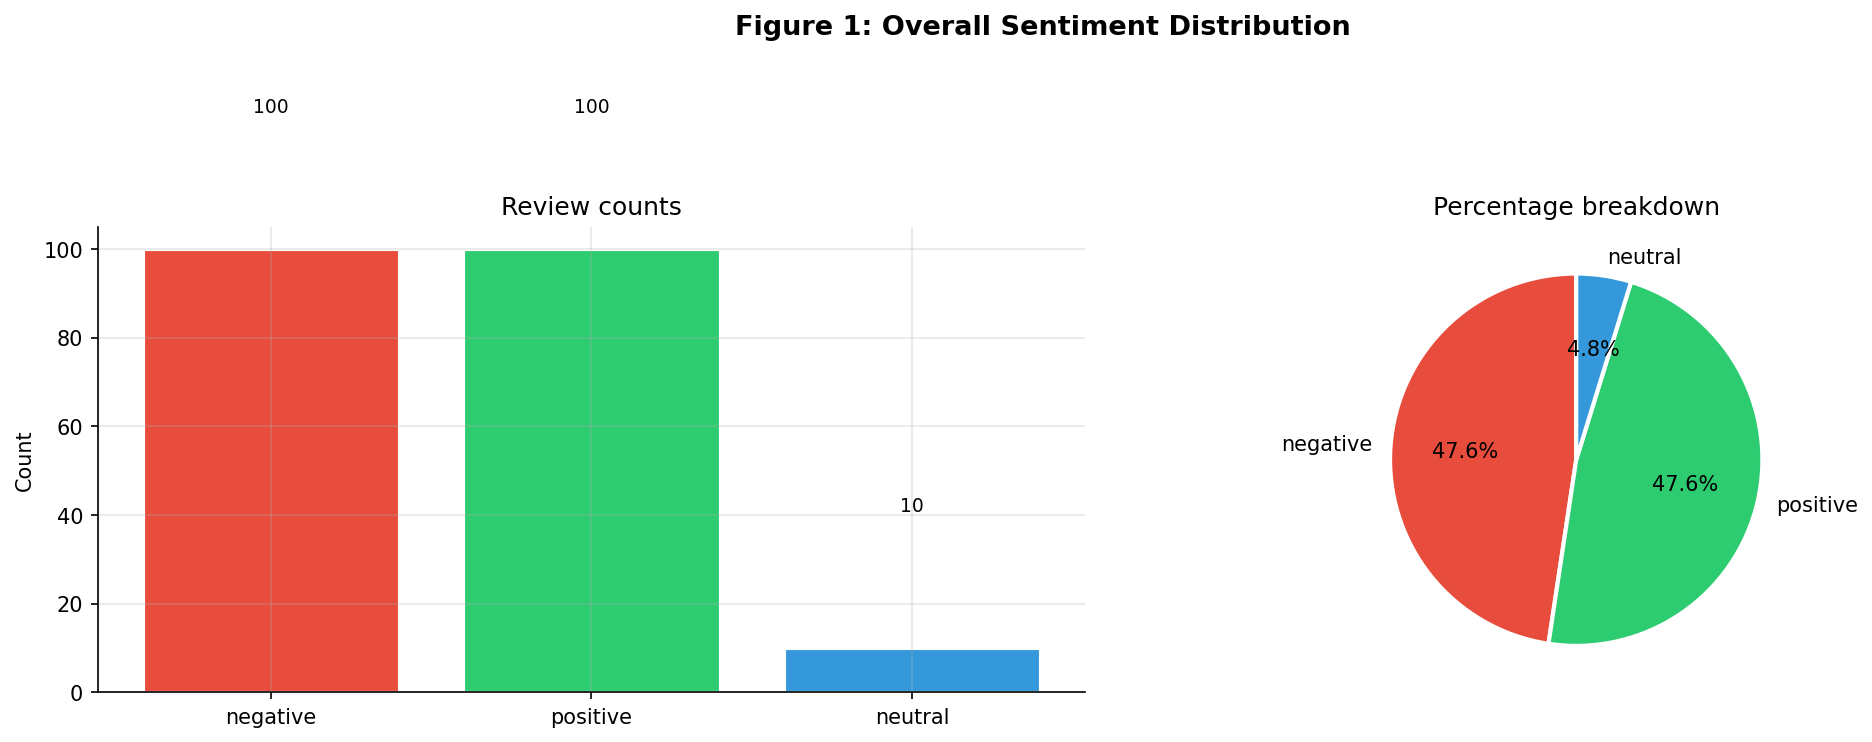

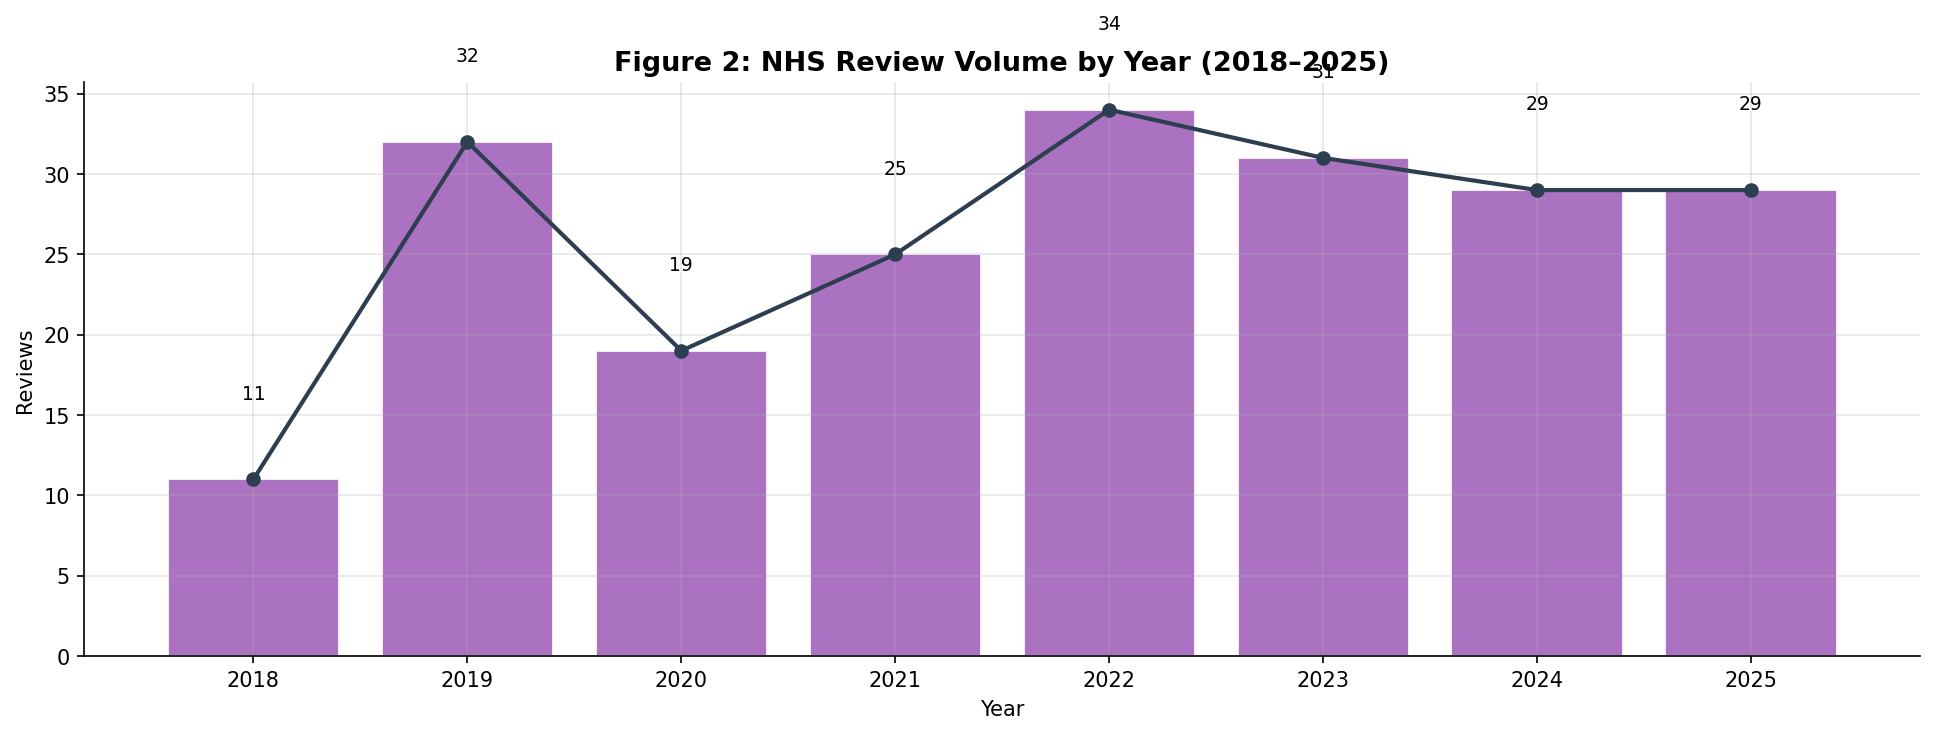

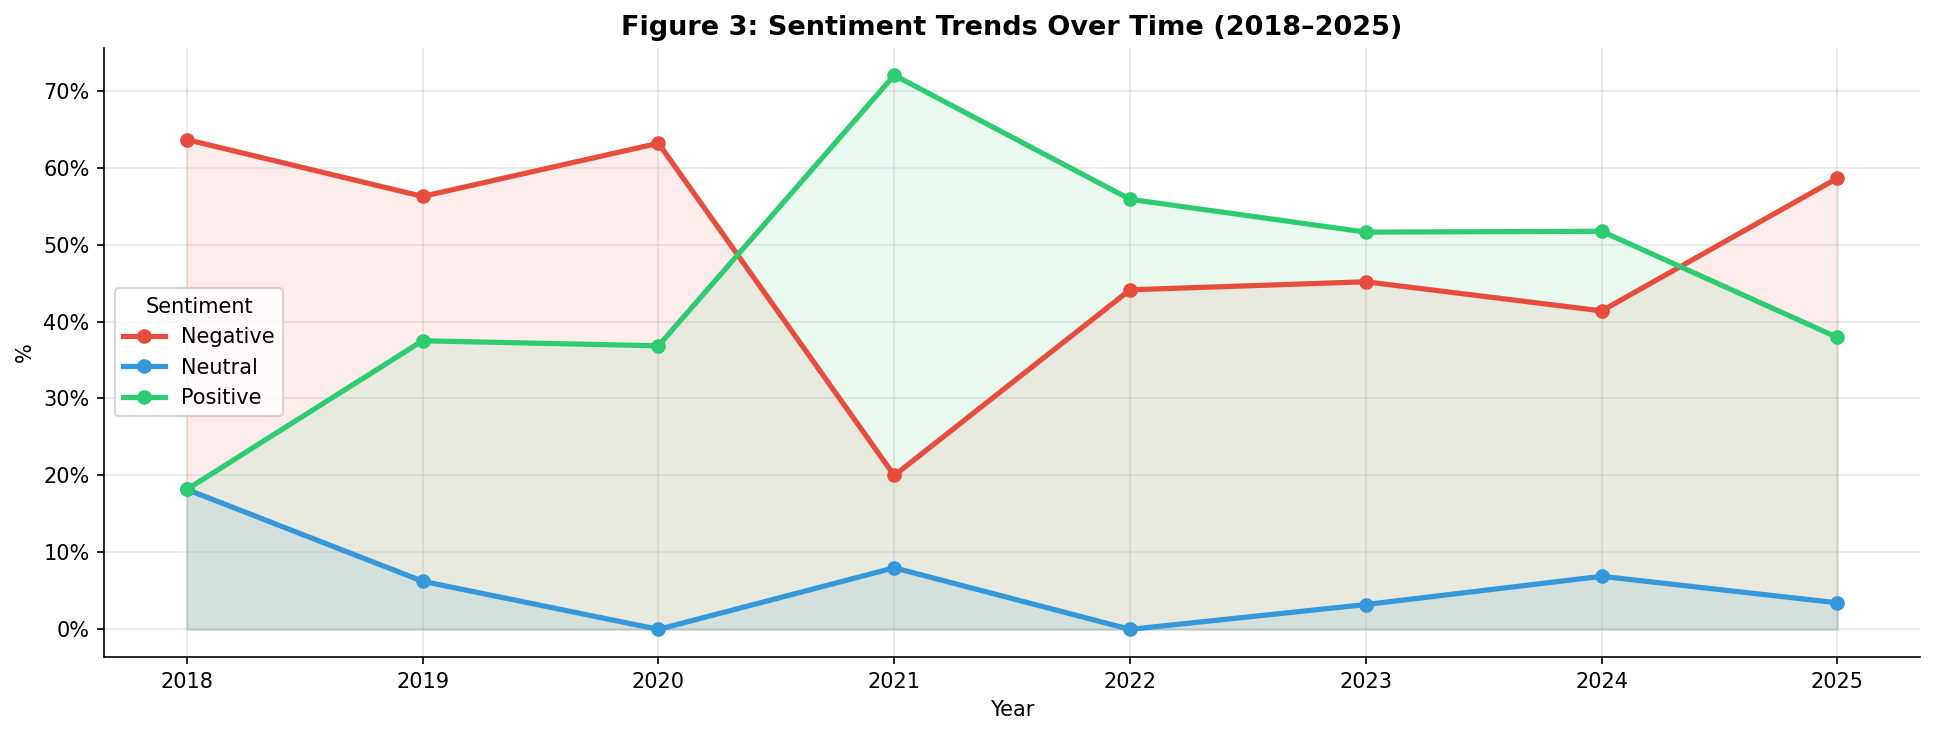

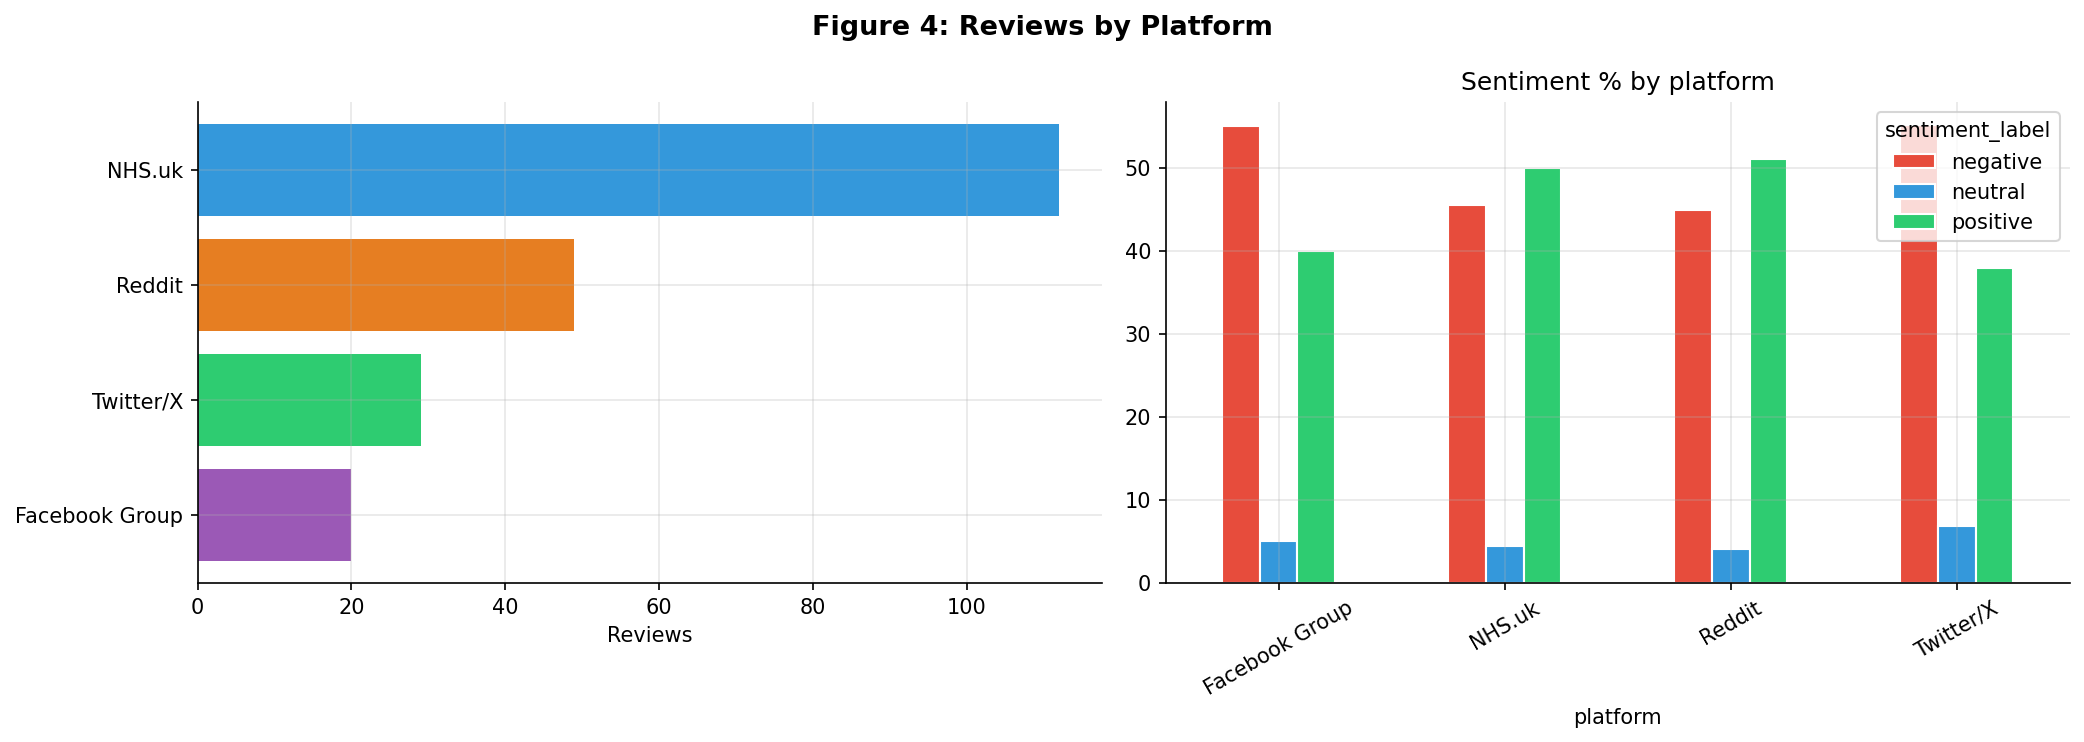

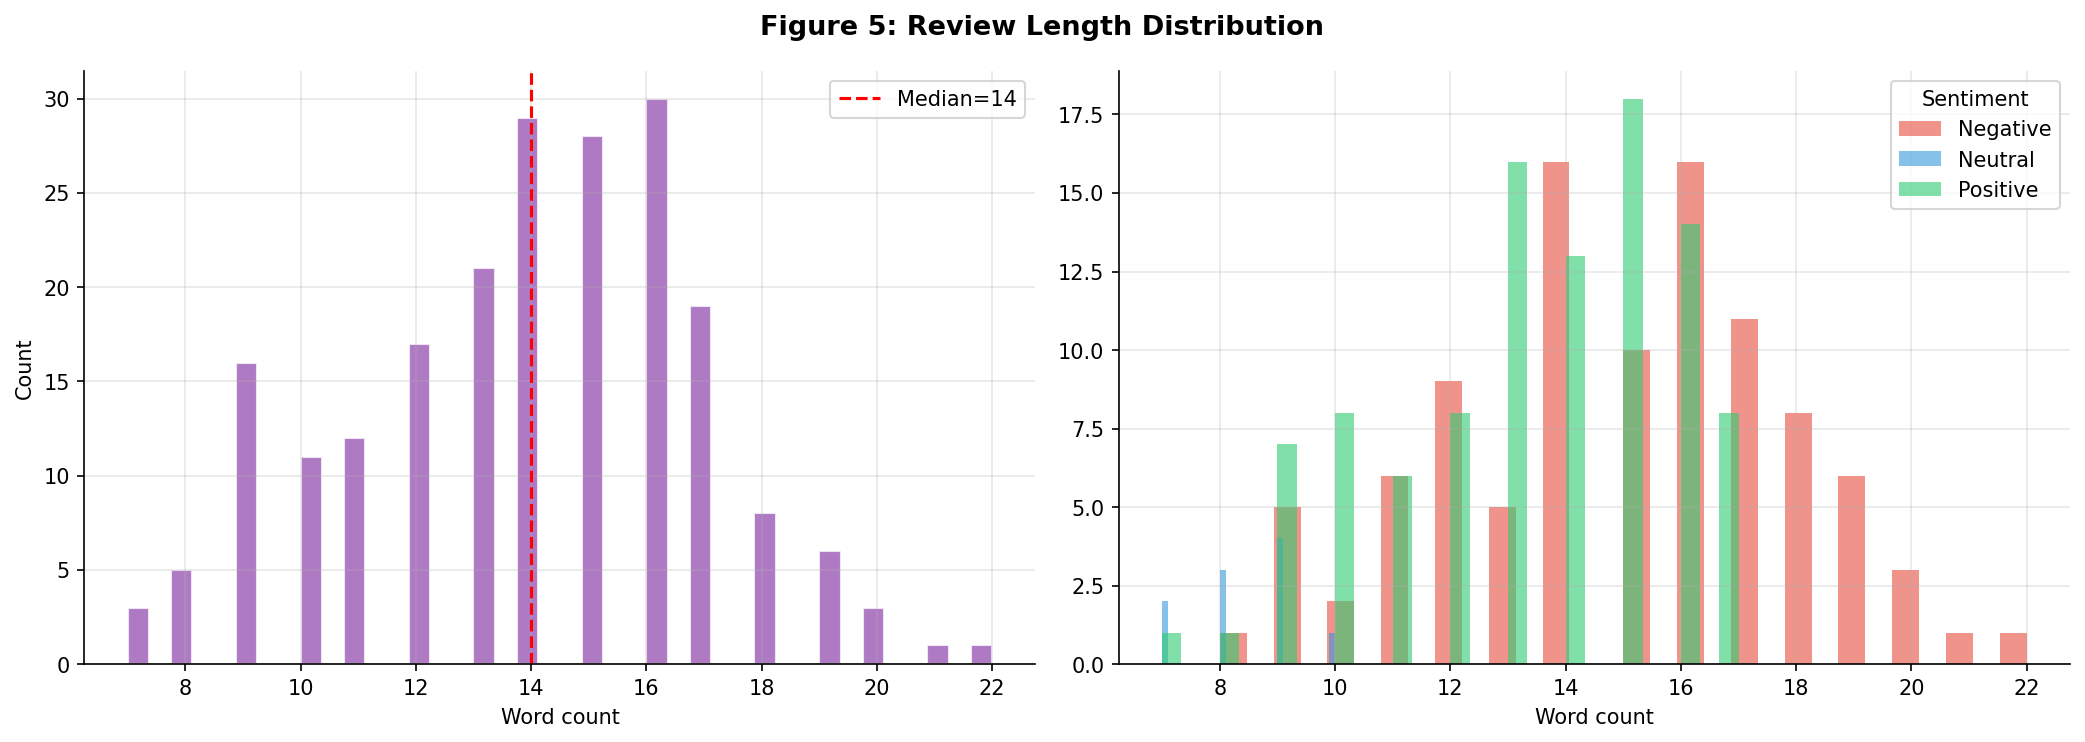

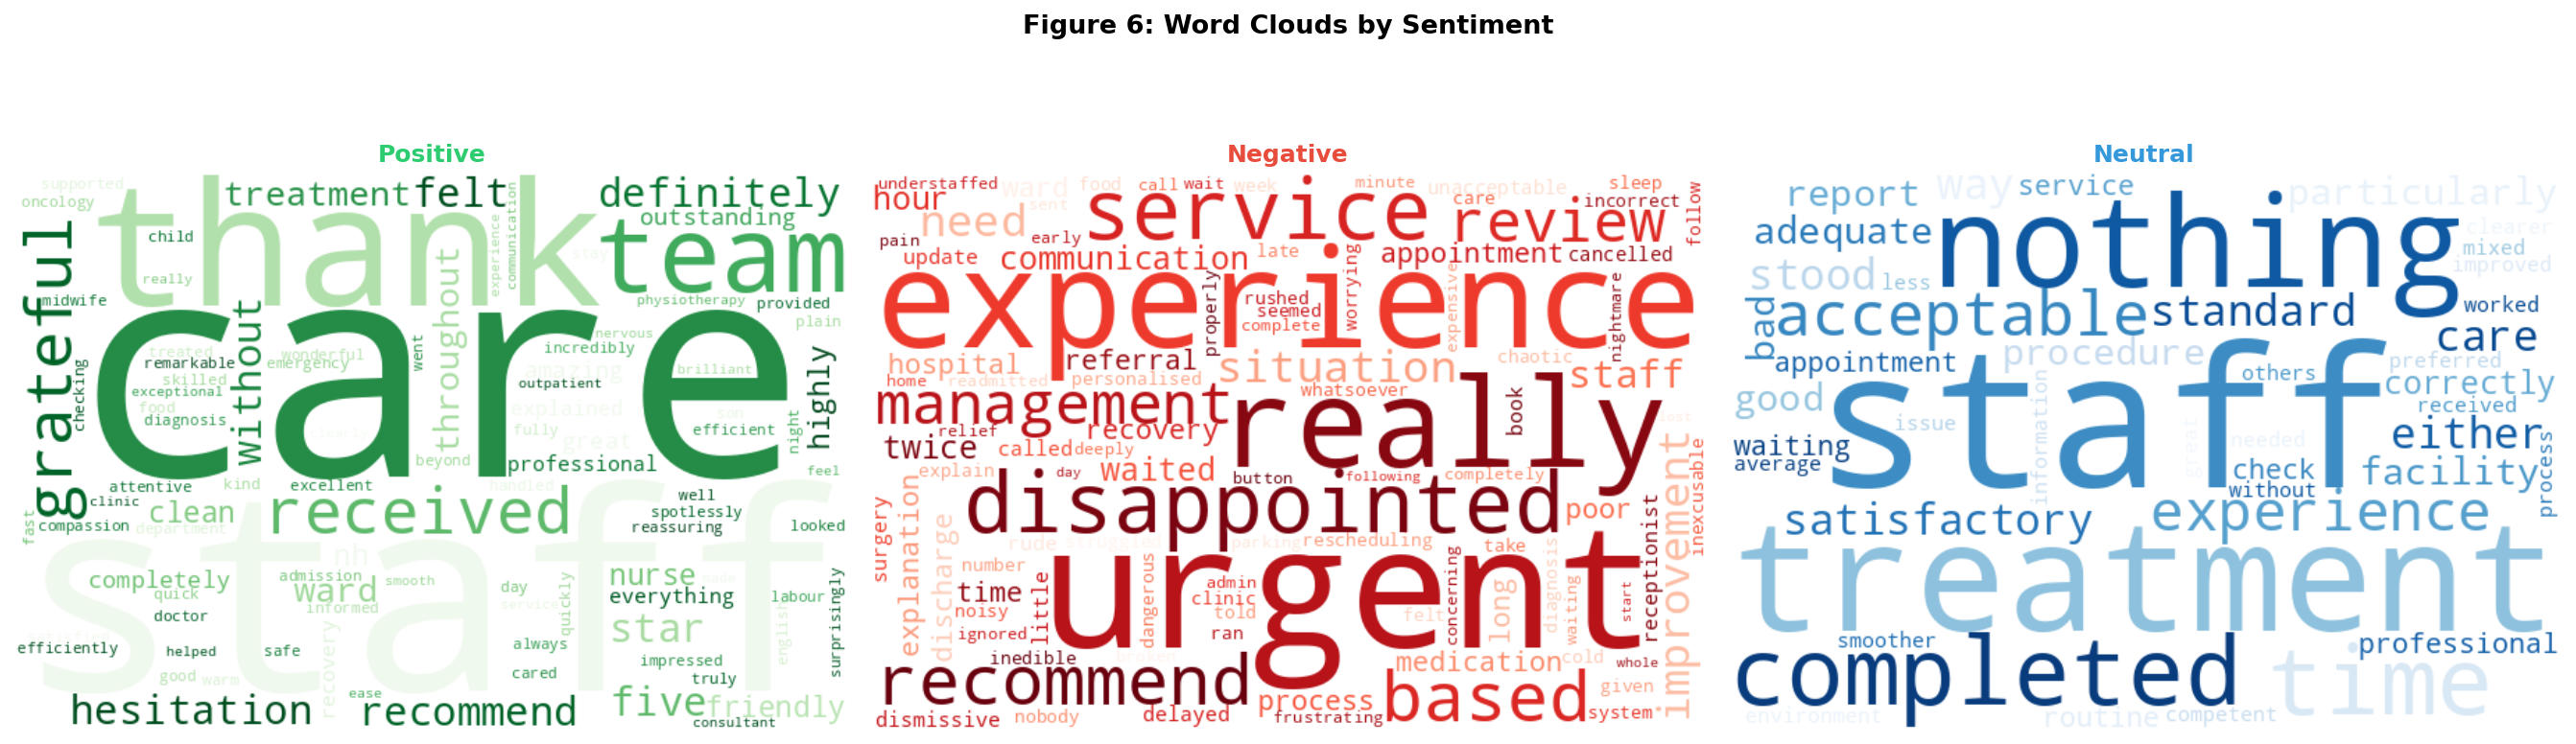

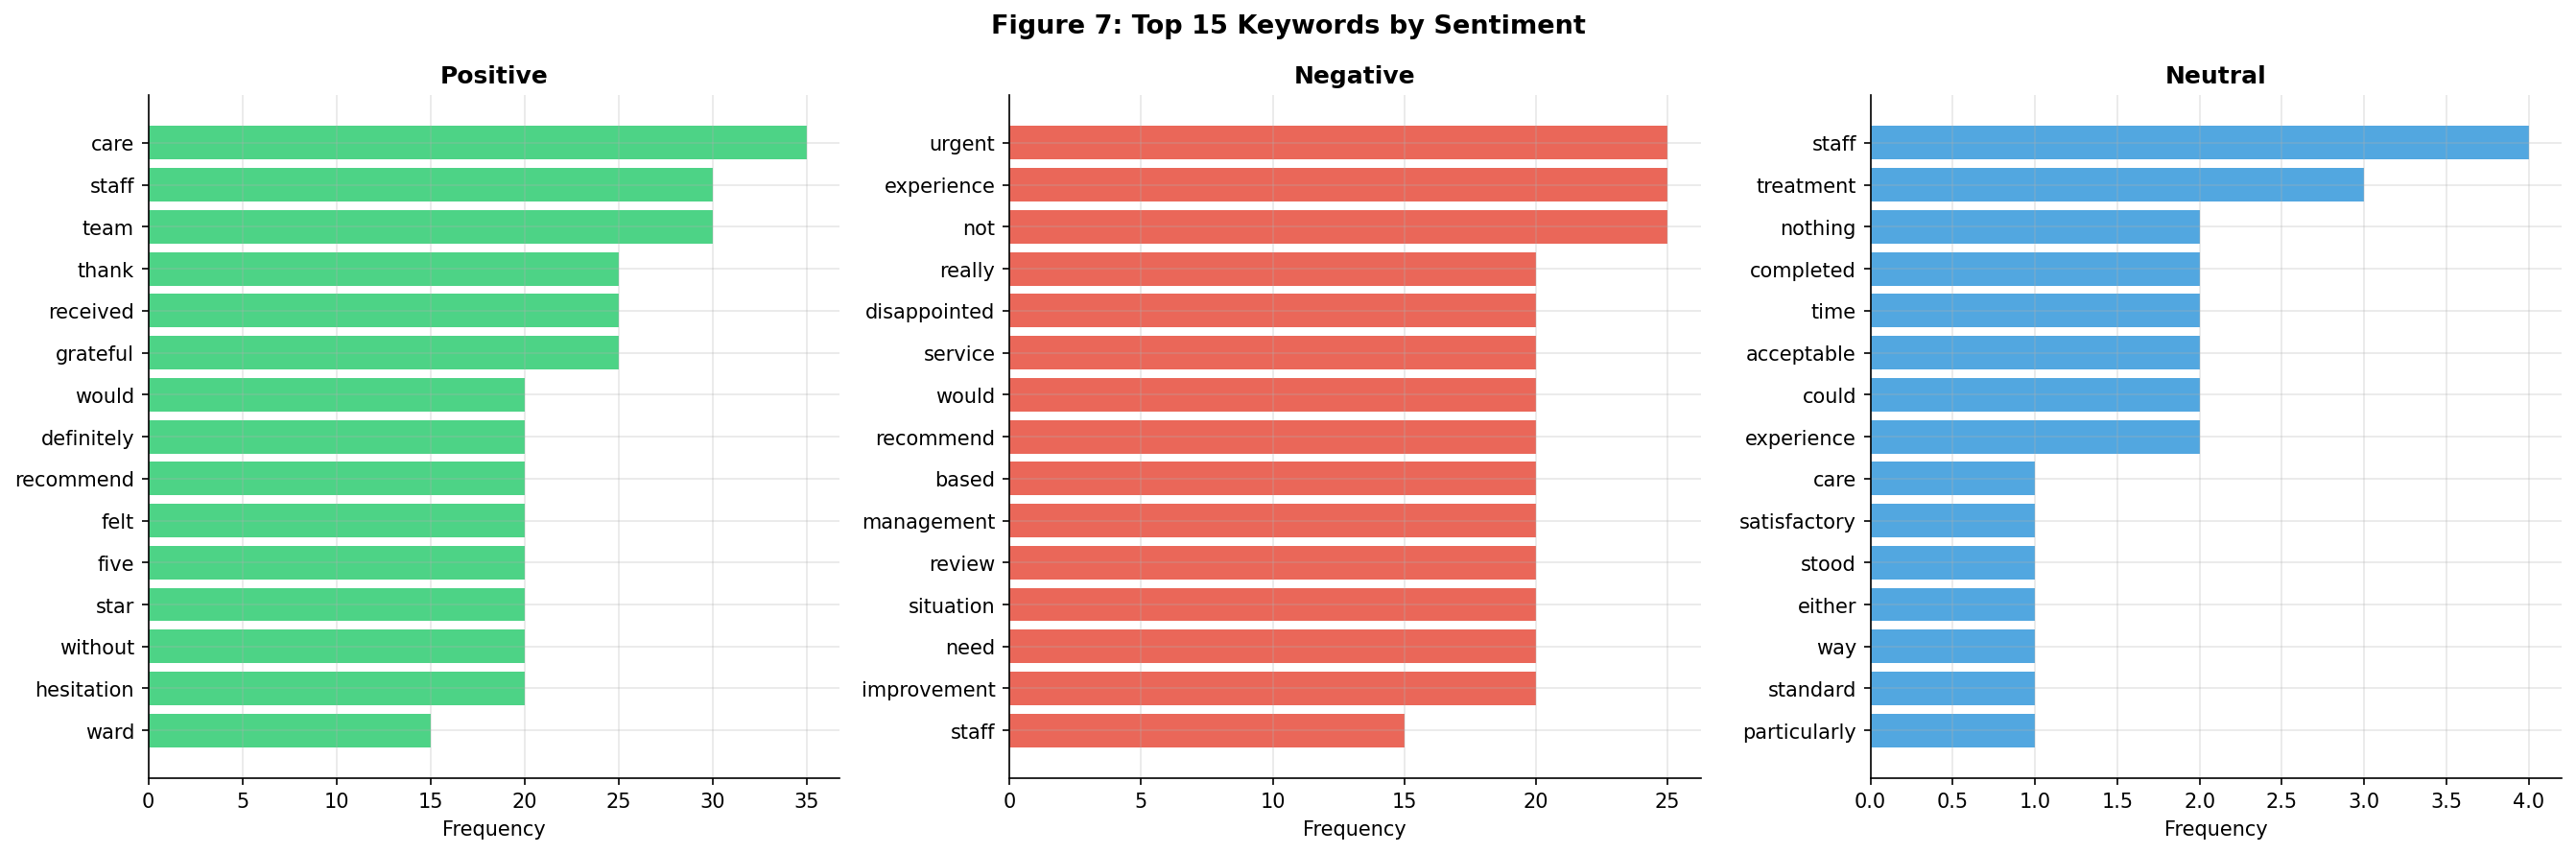

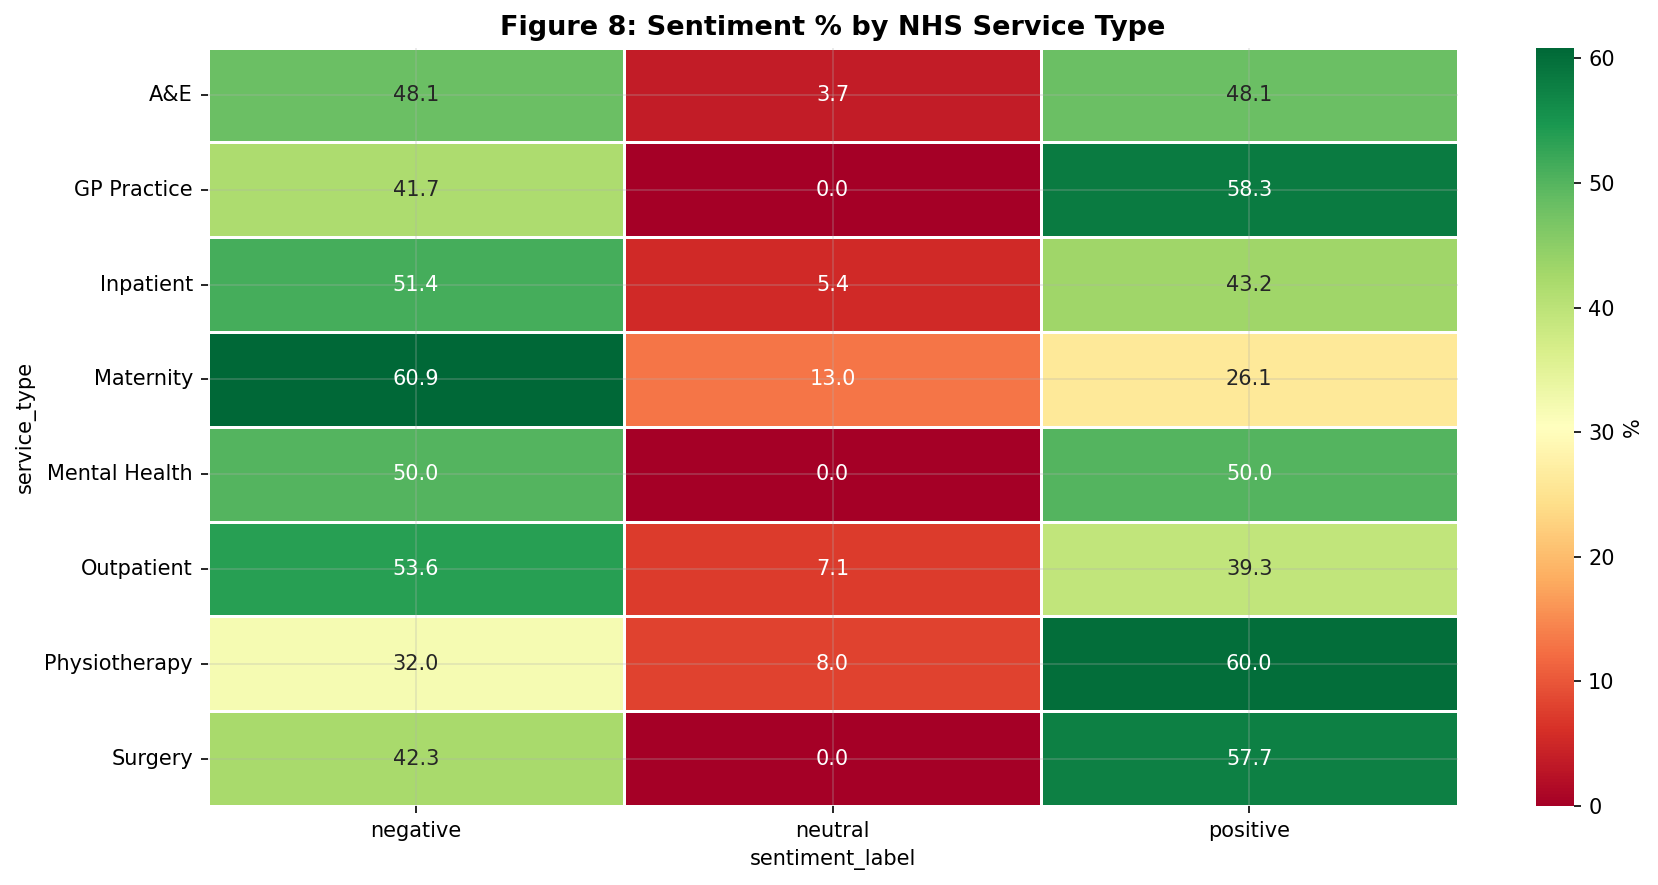

✅ Stage 3 EDA complete — 8 figures saved.


In [4]:
# ============================================================
# STAGE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

# Safe column resolution — works even if cells ran out of order
proc_col = 'processed_text' if 'processed_text' in df.columns else text_col
sent_col = next(
    (c for c in ['sentiment_label','ml_predicted_sentiment','sentiment','label']
     if c in df.columns), None
)
print(f'EDA using → proc_col={proc_col} | sent_col={sent_col} | rows={len(df):,}')

# Figure 1: Sentiment distribution
if sent_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Figure 1: Overall Sentiment Distribution', fontsize=13, fontweight='bold')
    counts  = df[sent_col].value_counts()
    palette = [COLORS.get(s,'#95a5a6') for s in counts.index]
    bars = axes[0].bar(counts.index, counts.values, color=palette, edgecolor='white', lw=1.5)
    axes[0].set_title('Review counts'); axes[0].set_ylabel('Count')
    for b, v in zip(bars, counts.values):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+30,
                     f'{v:,}', ha='center', va='bottom', fontsize=9)
    axes[1].pie(counts.values, labels=counts.index, colors=palette,
                autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor':'white','linewidth':2})
    axes[1].set_title('Percentage breakdown')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig1_sentiment_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 2: Yearly volume
if 'year' in df.columns:
    fig, ax = plt.subplots(figsize=(13, 5))
    yearly = df[df['year'].between(2018,2025)].groupby('year').size()
    bars   = ax.bar(yearly.index, yearly.values, color=COLORS['accent'], alpha=0.85, edgecolor='white')
    ax.plot(yearly.index, yearly.values, color=COLORS['primary'], marker='o', lw=2, zorder=5)
    for b, v in zip(bars, yearly.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{v:,}', ha='center', fontsize=9)
    ax.set_title('Figure 2: NHS Review Volume by Year (2018–2025)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('Reviews')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig2_yearly_volume.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 3: Yearly sentiment trends
if 'year' in df.columns and sent_col:
    fig, ax = plt.subplots(figsize=(13, 5))
    pivot_pct = (df[df['year'].between(2018,2025)]
                 .groupby(['year', sent_col]).size().unstack(fill_value=0)
                 .pipe(lambda x: x.div(x.sum(axis=1), axis=0)*100))
    for s in pivot_pct.columns:
        ax.plot(pivot_pct.index, pivot_pct[s], marker='o', lw=2.5,
                label=s.capitalize(), color=COLORS.get(s,'#95a5a6'))
        ax.fill_between(pivot_pct.index, pivot_pct[s], alpha=0.1, color=COLORS.get(s,'#95a5a6'))
    ax.set_title('Figure 3: Sentiment Trends Over Time (2018–2025)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year'); ax.set_ylabel('%')
    ax.legend(title='Sentiment'); ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig3_sentiment_trends.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 4: Platform distribution
if 'platform' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle('Figure 4: Reviews by Platform', fontsize=13, fontweight='bold')
    plat = df['platform'].value_counts()
    axes[0].barh(plat.index, plat.values, color=['#3498db','#e67e22','#2ecc71','#9b59b6'][:len(plat)])
    axes[0].set_xlabel('Reviews'); axes[0].invert_yaxis()
    if sent_col:
        cross = pd.crosstab(df['platform'], df[sent_col], normalize='index')*100
        cross.plot(kind='bar', ax=axes[1],
                   color=[COLORS.get(c,'#95a5a6') for c in cross.columns], edgecolor='white')
        axes[1].set_title('Sentiment % by platform'); axes[1].tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig4_platform_distribution.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 5: Review length
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Figure 5: Review Length Distribution', fontsize=13, fontweight='bold')
axes[0].hist(df['word_count'].clip(upper=200), bins=40, color=COLORS['accent'], alpha=0.8, edgecolor='white')
axes[0].axvline(df['word_count'].median(), color='red', linestyle='--',
                label=f"Median={df['word_count'].median():.0f}")
axes[0].set_xlabel('Word count'); axes[0].set_ylabel('Count'); axes[0].legend()
if sent_col:
    for s, g in df.groupby(sent_col):
        axes[1].hist(g['word_count'].clip(upper=200), bins=30, alpha=0.6,
                     label=s.capitalize(), color=COLORS.get(s,'#95a5a6'))
    axes[1].set_xlabel('Word count'); axes[1].legend(title='Sentiment')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_review_length.png', bbox_inches='tight', dpi=150)
plt.show()

# Figure 6: Word clouds
if sent_col:
    fig, axes = plt.subplots(1, 3, figsize=(18,6))
    fig.suptitle('Figure 6: Word Clouds by Sentiment', fontsize=13, fontweight='bold')
    for ax, s, cmap in zip(axes, ['positive','negative','neutral'], ['Greens','Reds','Blues']):
        blob = ' '.join(df[df[sent_col]==s][proc_col].dropna())
        if blob.strip():
            wc = WordCloud(width=600,height=400,background_color='white',
                           colormap=cmap,max_words=100,collocations=False).generate(blob)
            ax.imshow(wc, interpolation='bilinear')
        ax.set_title(s.capitalize(), fontweight='bold', color=COLORS.get(s,'#333'))
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig6_wordclouds.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 7: Top keywords
if sent_col:
    fig, axes = plt.subplots(1, 3, figsize=(18,6))
    fig.suptitle('Figure 7: Top 15 Keywords by Sentiment', fontsize=13, fontweight='bold')
    for ax, s in zip(axes, ['positive','negative','neutral']):
        words = ' '.join(df[df[sent_col]==s][proc_col].dropna()).split()
        freq  = Counter(words).most_common(15)
        if freq:
            w, c = zip(*freq)
            ax.barh(list(w)[::-1], list(c)[::-1], color=COLORS.get(s,'#95a5a6'), alpha=0.85)
        ax.set_title(s.capitalize(), fontweight='bold')
        ax.set_xlabel('Frequency')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig7_top_keywords.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 8: Heatmap
if 'service_type' in df.columns and sent_col:
    fig, ax = plt.subplots(figsize=(12,6))
    heat = pd.crosstab(df['service_type'], df[sent_col], normalize='index')*100
    sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn',
                linewidths=0.5, ax=ax, cbar_kws={'label':'%'})
    ax.set_title('Figure 8: Sentiment % by NHS Service Type', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig8_service_heatmap.png', bbox_inches='tight', dpi=150)
    plt.show()

print('✅ Stage 3 EDA complete — 8 figures saved.')

Running VADER + TextBlob...
VADER distribution:
vader_sentiment
positive    125
negative     69
neutral      16
Name: count, dtype: int64


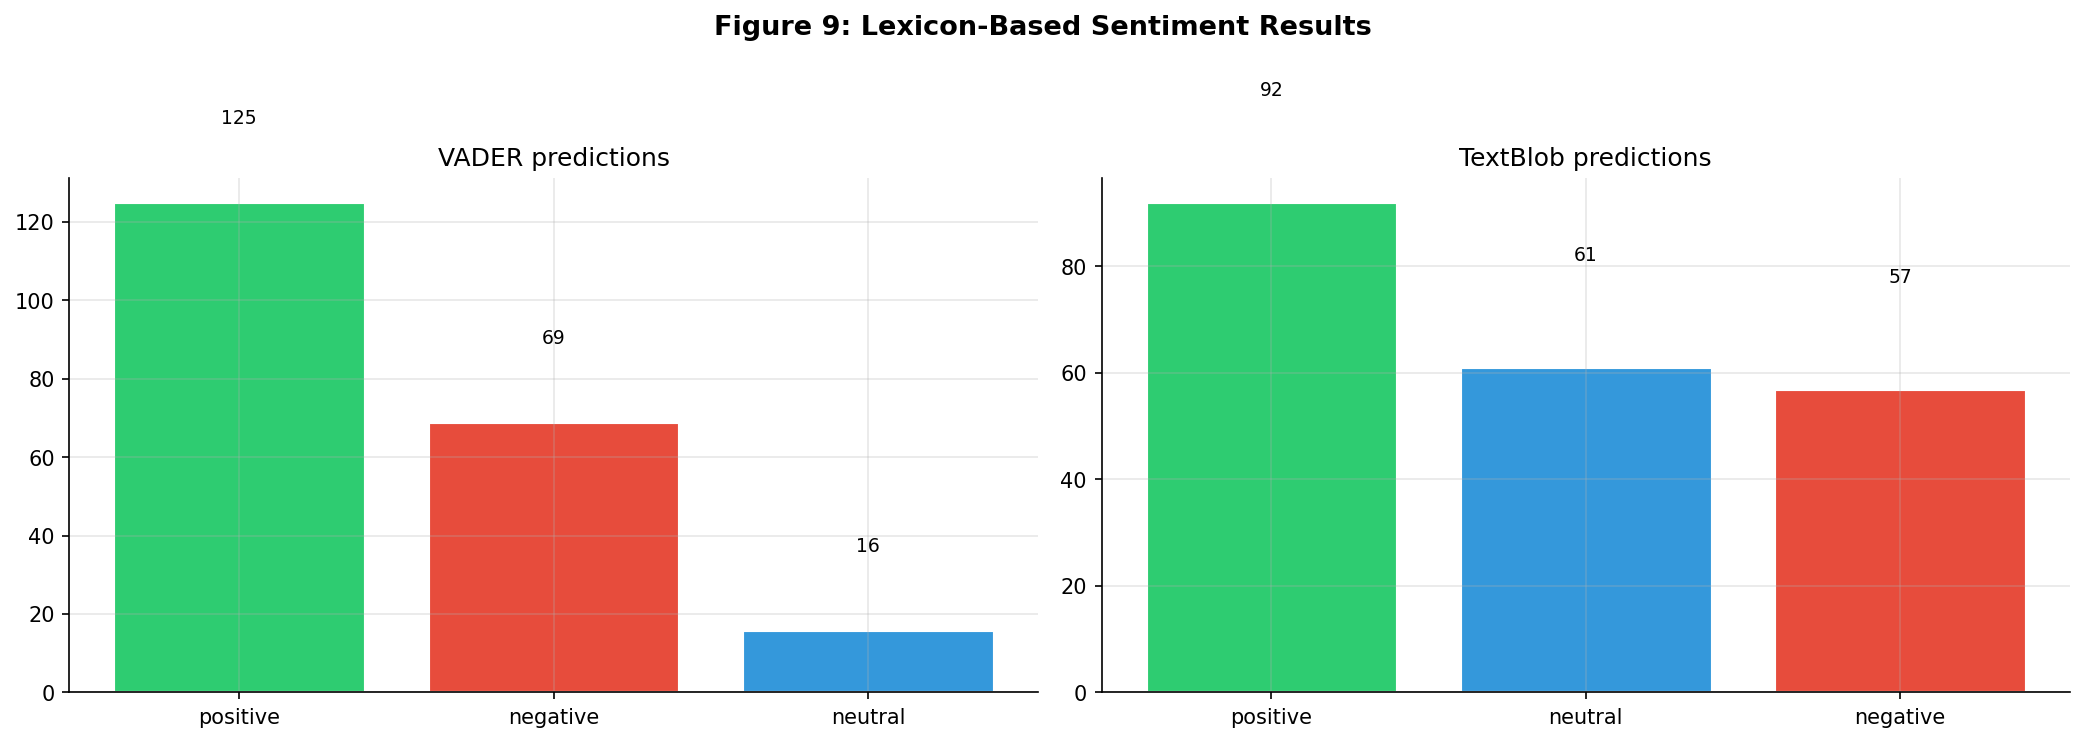

Corpus: 210 docs → min_df=1
TF-IDF matrix: 210 docs × 641 features
  Training Logistic Regression...
    Accuracy=0.9524 | F1=0.6508
  Training Naive Bayes...
    Accuracy=0.9524 | F1=0.6508
  Training Linear SVM...
    Accuracy=0.9524 | F1=0.6508
  Training Random Forest...
    Accuracy=0.9524 | F1=0.6504


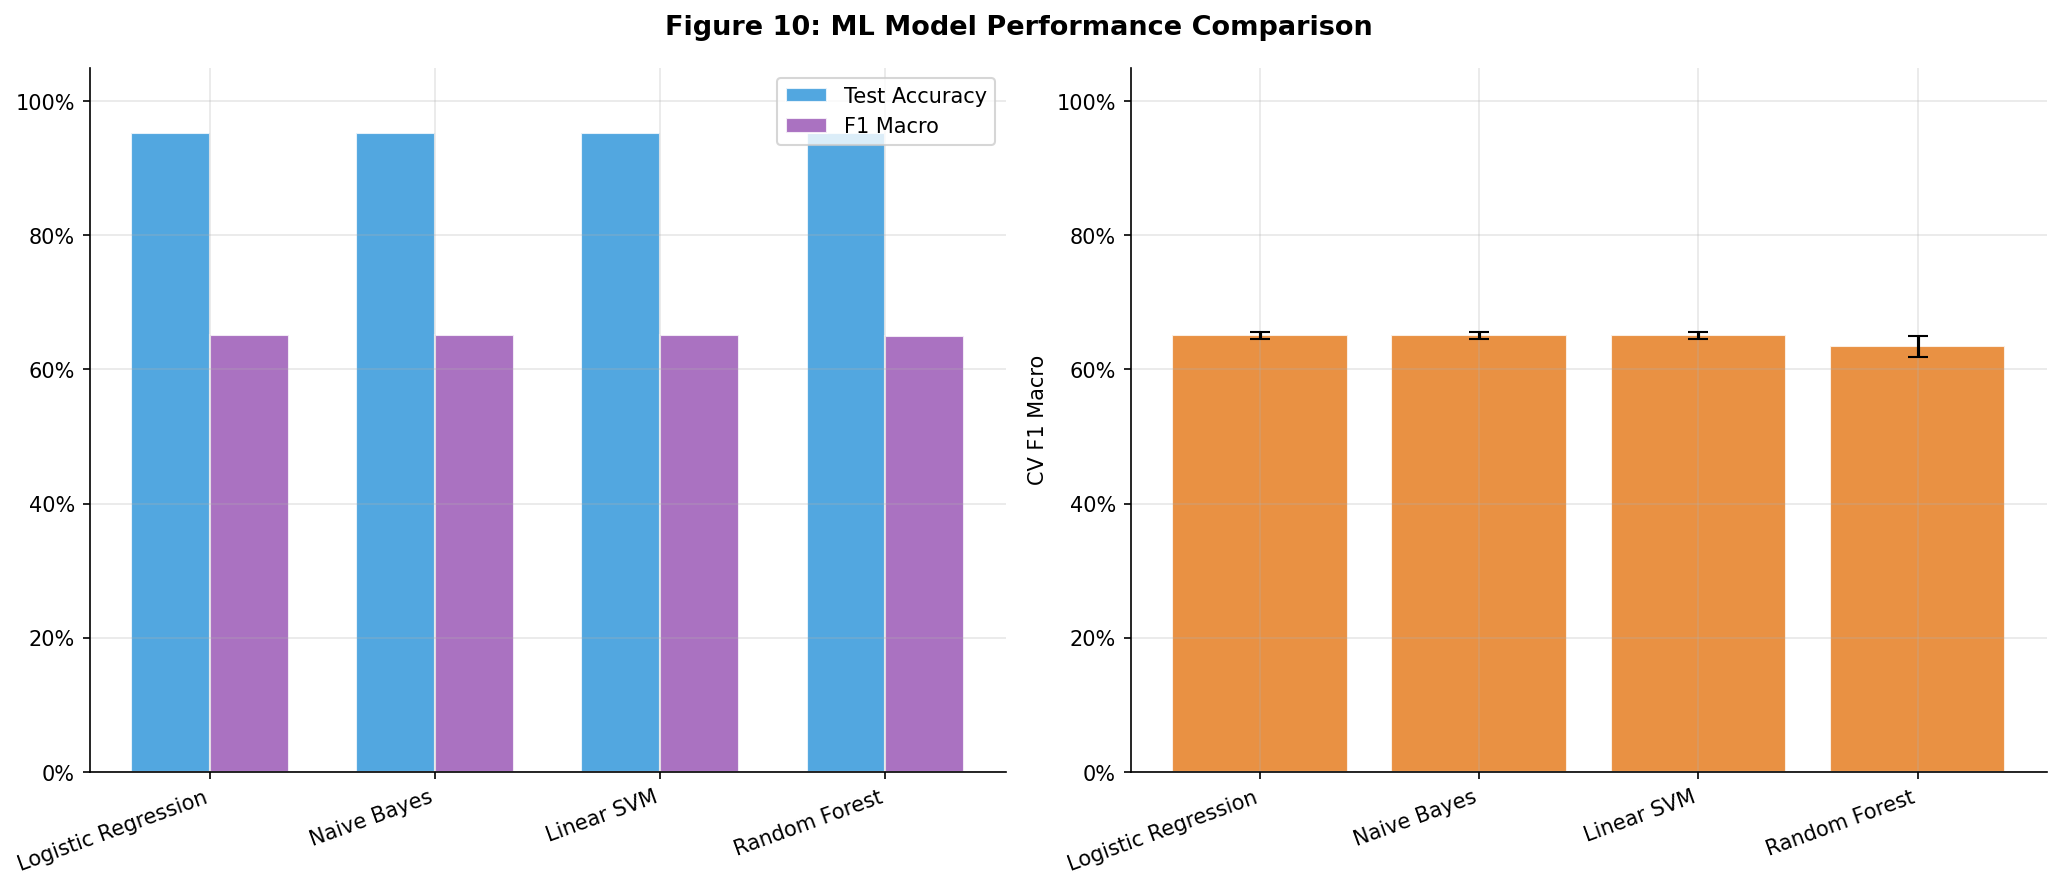


🏆 Best model: Logistic Regression (F1=0.6508)
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        20
     neutral       0.00      0.00      0.00         2
    positive       0.91      1.00      0.95        20

    accuracy                           0.95        42
   macro avg       0.64      0.67      0.65        42
weighted avg       0.91      0.95      0.93        42



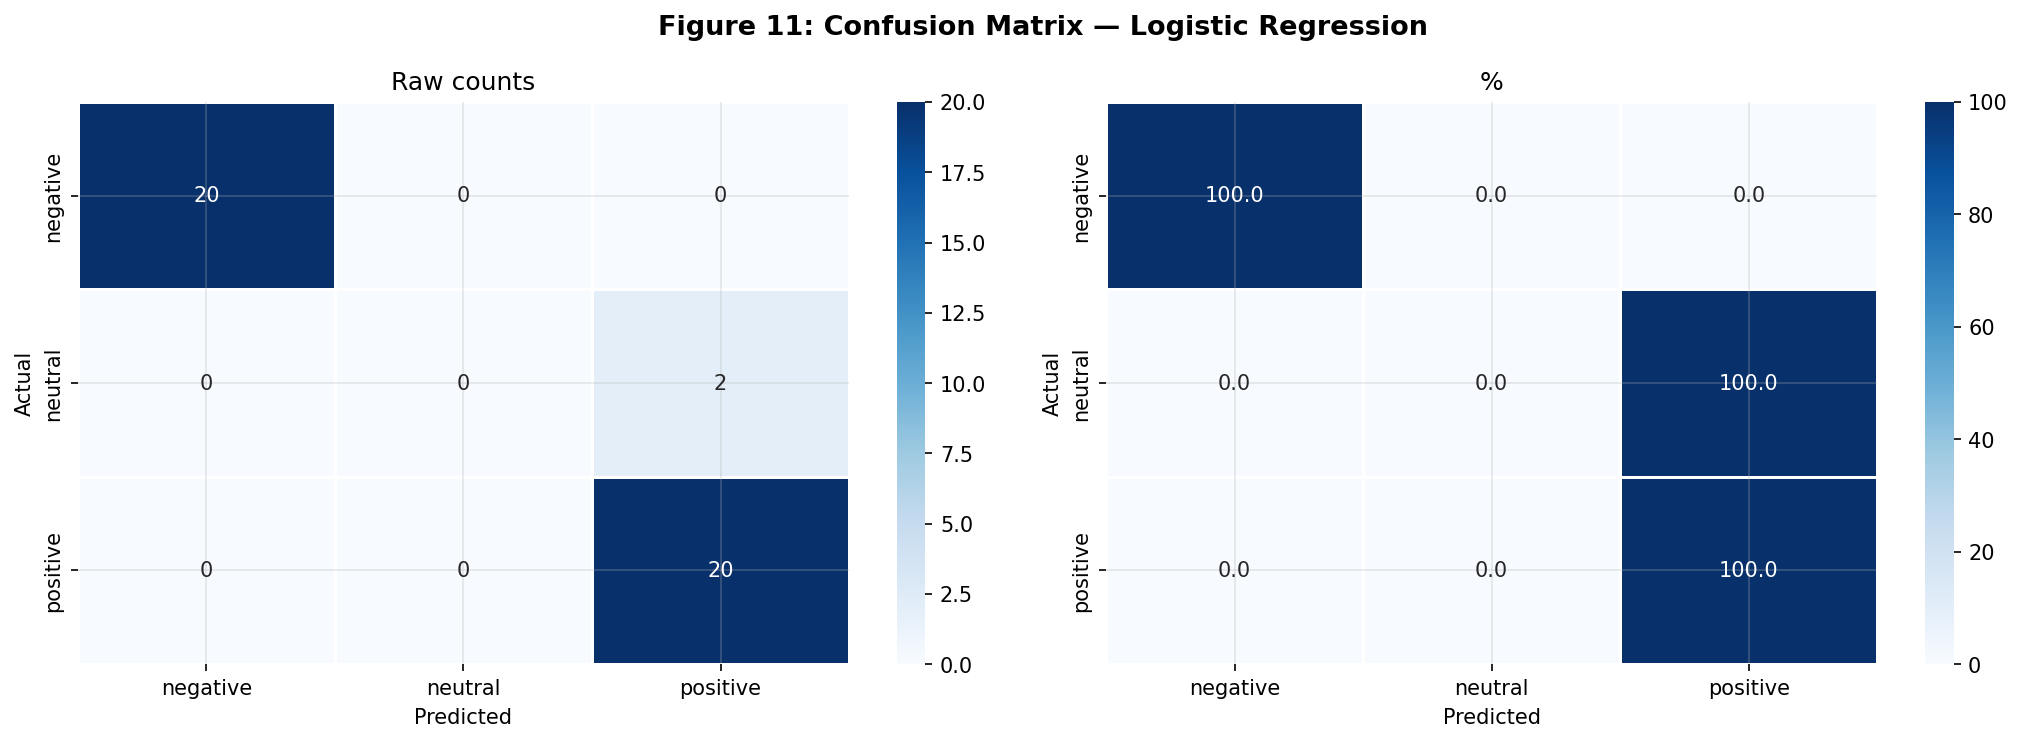

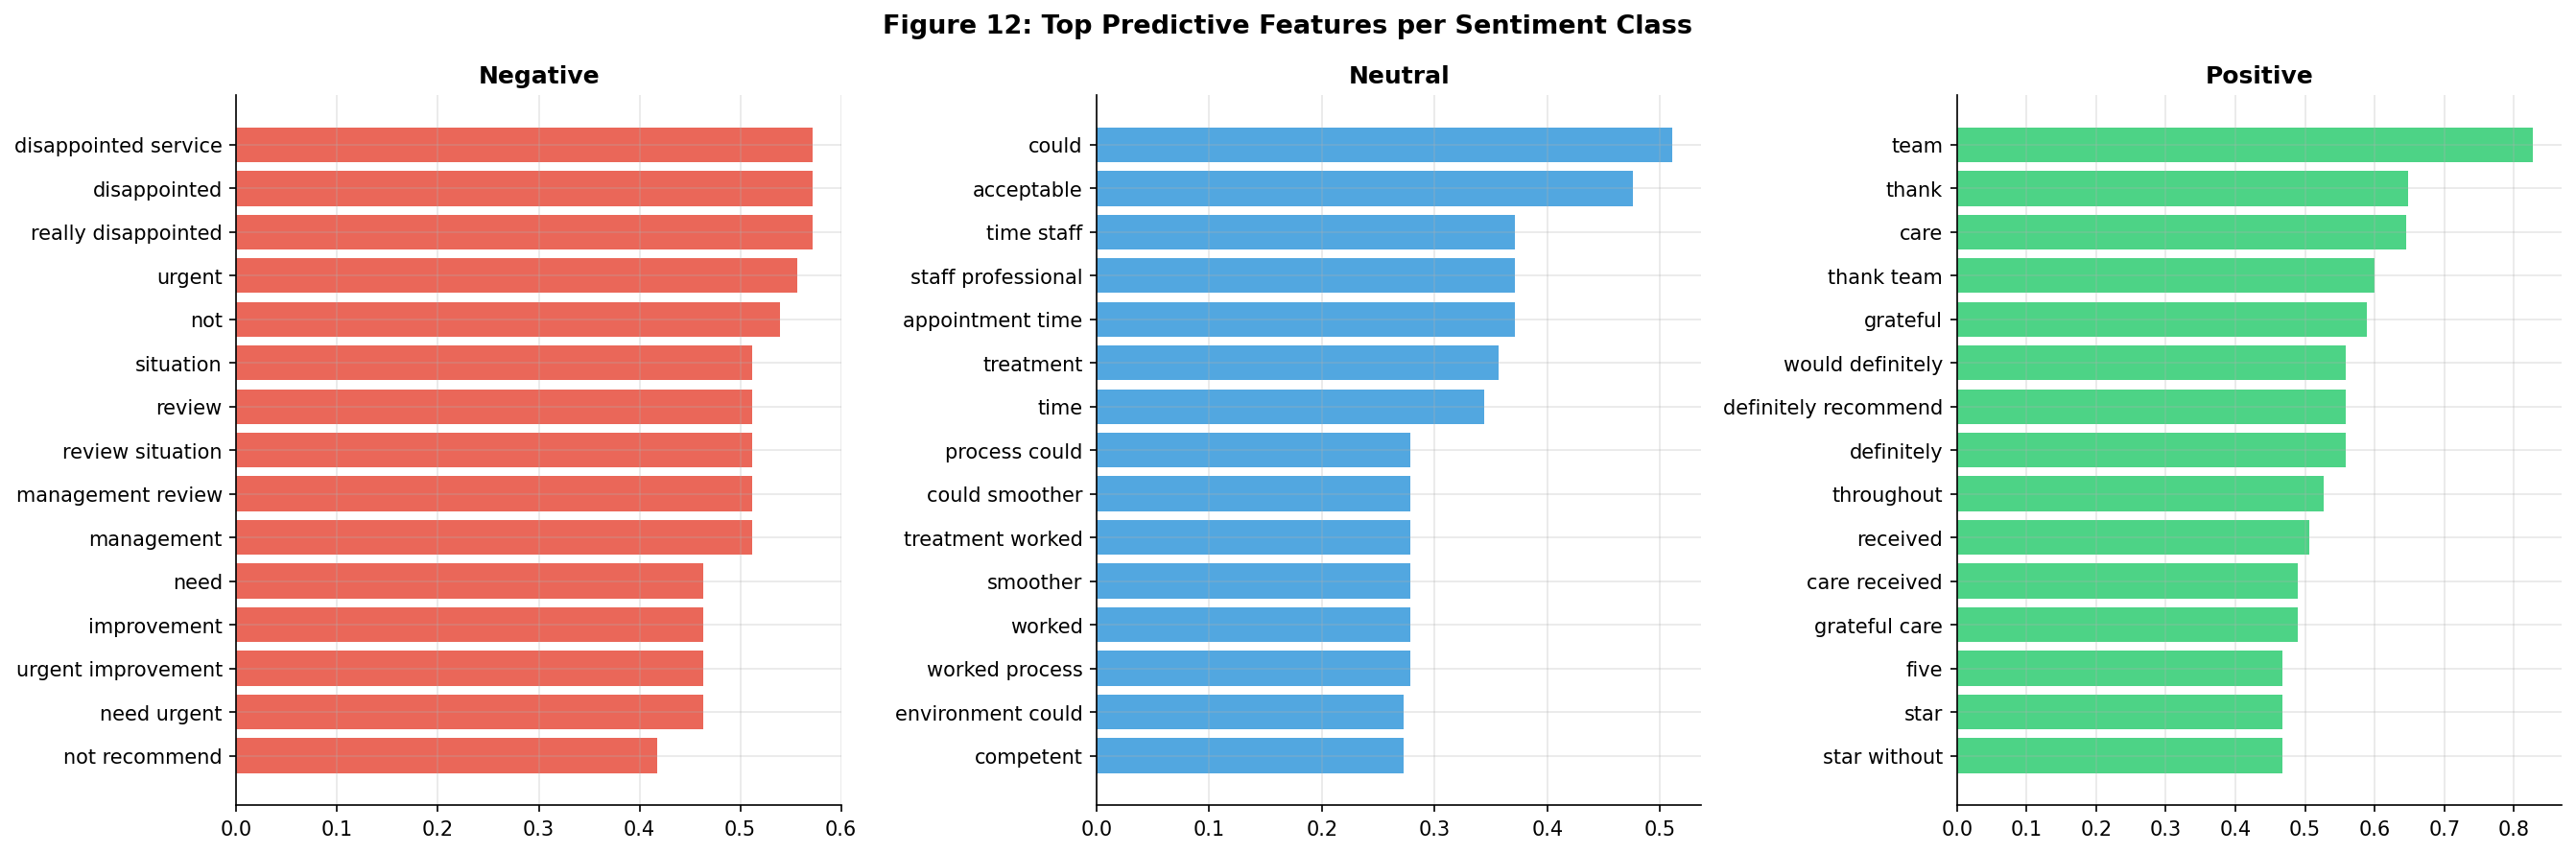


✅ Stages 4 & 5 complete. Predictions saved.


In [5]:
# ============================================================
# STAGE 4 & 5: FEATURE EXTRACTION + SENTIMENT CLASSIFICATION
# ============================================================

sia = SentimentIntensityAnalyzer()

# --- Lexicon-based ---
def vader_label(text):
    s = sia.polarity_scores(str(text))['compound']
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

def textblob_label(text):
    s = TextBlob(str(text)).sentiment.polarity
    return 'positive' if s > 0.1 else ('negative' if s < -0.1 else 'neutral')

print('Running VADER + TextBlob...')
df['vader_compound']      = df[proc_col].apply(lambda t: sia.polarity_scores(str(t))['compound'])
df['textblob_polarity']   = df[proc_col].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
df['vader_sentiment']     = df[proc_col].apply(vader_label)
df['textblob_sentiment']  = df[proc_col].apply(textblob_label)

print('VADER distribution:')
print(df['vader_sentiment'].value_counts())

# Figure 9: Lexicon results
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Figure 9: Lexicon-Based Sentiment Results', fontsize=13, fontweight='bold')
for ax, col, title in zip(axes, ['vader_sentiment','textblob_sentiment'], ['VADER','TextBlob']):
    counts  = df[col].value_counts()
    palette = [COLORS.get(s,'#95a5a6') for s in counts.index]
    bars = ax.bar(counts.index, counts.values, color=palette, edgecolor='white', lw=1.5)
    ax.set_title(f'{title} predictions')
    for b, v in zip(bars, counts.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+20,
                f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig9_lexicon_results.png', bbox_inches='tight', dpi=150)
plt.show()

# --- TF-IDF + ML Models ---
# Dynamic min_df: scales with corpus size to avoid empty-vocabulary crash
n_docs = len(df)
min_df = 1 if n_docs < 500 else (2 if n_docs < 2000 else 3)
print(f'Corpus: {n_docs:,} docs → min_df={min_df}')

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=min_df,
    max_df=0.98,       # raised to keep more terms
    sublinear_tf=True
)
X_tfidf = tfidf.fit_transform(df[proc_col].fillna(''))
feature_names = np.array(tfidf.get_feature_names_out())
print(f'TF-IDF matrix: {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} features')

results = {}
if sent_col and df[sent_col].nunique() >= 2:
    le = LabelEncoder()
    y  = le.fit_transform(df[sent_col])
    X_train, X_test, y_train, y_test = train_test_split(
        X_tfidf, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
        'Naive Bayes':         MultinomialNB(alpha=0.5),
        'Linear SVM':          LinearSVC(max_iter=2000, C=1.0, random_state=42),
        'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for name, model in models.items():
        print(f'  Training {name}...')
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        cv_sc  = cross_val_score(model, X_train, y_train, cv=cv,
                                 scoring='f1_macro', n_jobs=-1)
        results[name] = {
            'model': model, 'y_pred': y_pred,
            'accuracy':    accuracy_score(y_test, y_pred),
            'f1_macro':    f1_score(y_test, y_pred, average='macro'),
            'f1_weighted': f1_score(y_test, y_pred, average='weighted'),
            'cv_mean': cv_sc.mean(), 'cv_std': cv_sc.std(),
        }
        print(f'    Accuracy={results[name]["accuracy"]:.4f} | F1={results[name]["f1_macro"]:.4f}')

    # Figure 10: Model comparison
    names = list(results.keys())
    x, w  = np.arange(len(names)), 0.35
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    fig.suptitle('Figure 10: ML Model Performance Comparison', fontsize=13, fontweight='bold')
    axes[0].bar(x-w/2, [results[n]['accuracy']    for n in names], w,
                label='Test Accuracy', color='#3498db', alpha=0.85, edgecolor='white')
    axes[0].bar(x+w/2, [results[n]['f1_macro']    for n in names], w,
                label='F1 Macro',     color='#9b59b6', alpha=0.85, edgecolor='white')
    axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha='right')
    axes[0].set_ylim(0,1.05); axes[0].legend()
    axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    cv_means = [results[n]['cv_mean'] for n in names]
    cv_stds  = [results[n]['cv_std']  for n in names]
    axes[1].bar(x, cv_means, color='#e67e22', alpha=0.85, edgecolor='white',
                yerr=cv_stds, capsize=5)
    axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha='right')
    axes[1].set_ylim(0,1.05); axes[1].set_ylabel('CV F1 Macro')
    axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig10_model_comparison.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Best model
    best_name = max(results, key=lambda n: results[n]['f1_macro'])
    best = results[best_name]
    print(f'\n🏆 Best model: {best_name} (F1={best["f1_macro"]:.4f})')
    print(classification_report(y_test, best['y_pred'], target_names=le.classes_))

    # Figure 11: Confusion matrix
    cm     = confusion_matrix(y_test, best['y_pred'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, axes = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f'Figure 11: Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
    for ax, data, fmt, title in zip(axes, [cm, cm_pct], ['d','.1f'], ['Raw counts','%']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                    xticklabels=le.classes_, yticklabels=le.classes_,
                    linewidths=0.5, ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig11_confusion_matrix.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Figure 12: Feature importance
    lr_model  = results['Logistic Regression']['model']
    n_classes = len(le.classes_)
    fig, axes = plt.subplots(1, n_classes, figsize=(6*n_classes, 6))
    if n_classes == 1: axes = [axes]
    fig.suptitle('Figure 12: Top Predictive Features per Sentiment Class', fontsize=13, fontweight='bold')
    for ax, cidx, cname in zip(axes, range(n_classes), le.classes_):
        coefs = lr_model.coef_[cidx] if lr_model.coef_.ndim > 1 else lr_model.coef_[0]
        top15 = np.argsort(coefs)[-15:]
        ax.barh(feature_names[top15], coefs[top15],
                color=COLORS.get(cname,'#95a5a6'), alpha=0.85)
        ax.set_title(cname.capitalize(), fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig12_feature_importance.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Save predictions
    df['ml_predicted_sentiment'] = le.inverse_transform(
        results[best_name]['model'].predict(X_tfidf)
    )
    sent_col = 'ml_predicted_sentiment'

    # Save comparison table
    pd.DataFrame({
        'Model':       names,
        'Accuracy':    [round(results[n]['accuracy'],4)    for n in names],
        'F1_Macro':    [round(results[n]['f1_macro'],4)    for n in names],
        'F1_Weighted': [round(results[n]['f1_weighted'],4) for n in names],
        'CV_F1_Mean':  [round(results[n]['cv_mean'],4)     for n in names],
    }).sort_values('F1_Macro', ascending=False).to_csv(
        f'{OUTPUT_DIR}/model_comparison.csv', index=False
    )

df.to_csv(f'{OUTPUT_DIR}/nhs_with_predictions.csv', index=False)
print('\n✅ Stages 4 & 5 complete. Predictions saved.')

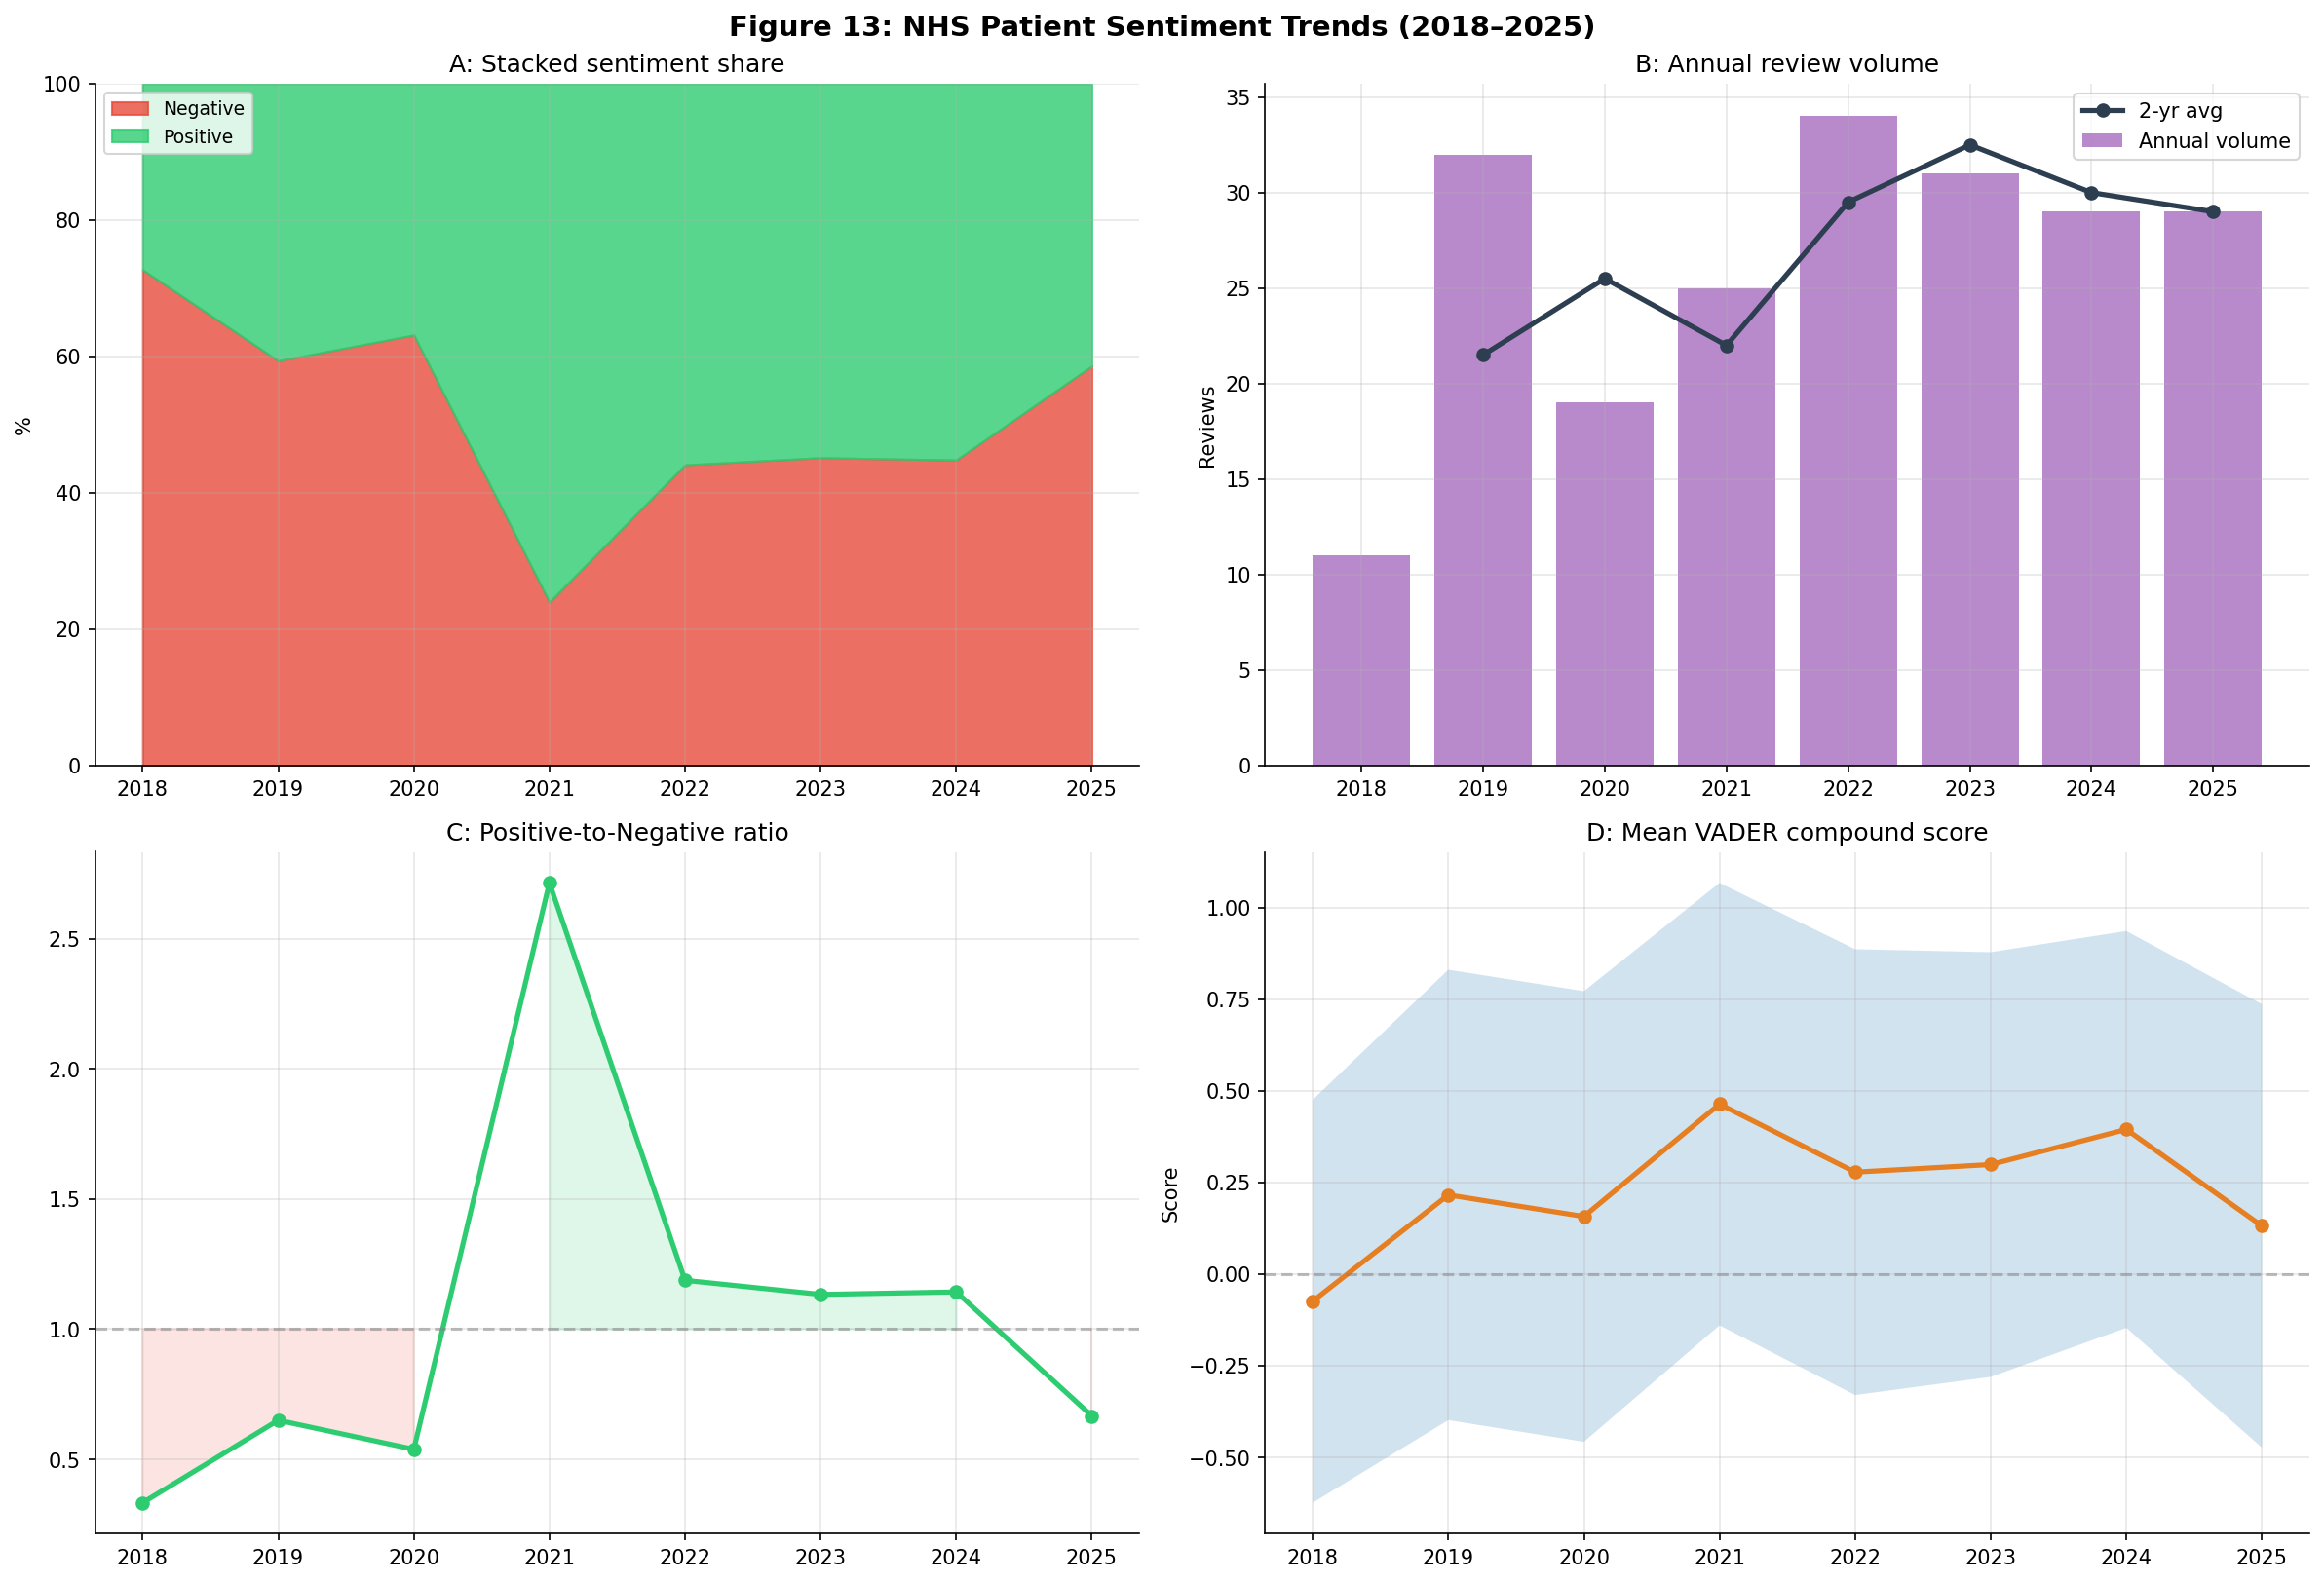

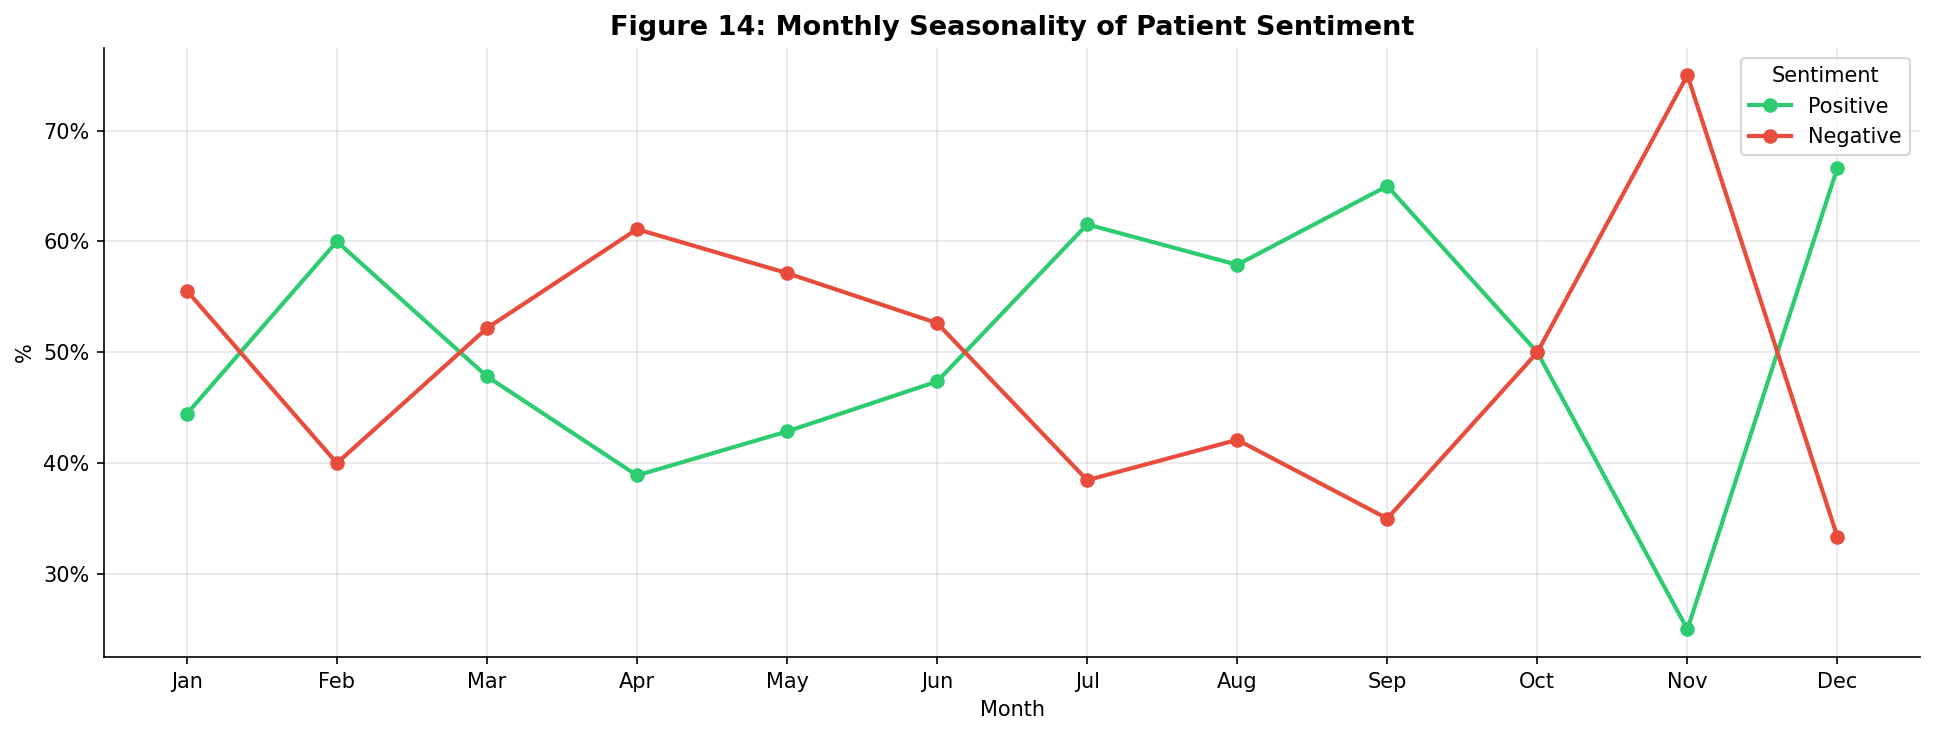

Topic 1: staff, received, grateful, care received, grateful care, without
Topic 2: review, management, management review, situation, review situation, service
Topic 3: recovery, great, treatment, well looked, safe, treatment felt
Topic 4: definitely recommend, definitely, would definitely, would, recommend, care
Topic 5: experience, not, based, based experience, recommend based, would not
Topic 6: urgent improvement, need urgent, urgent, need, improvement, care


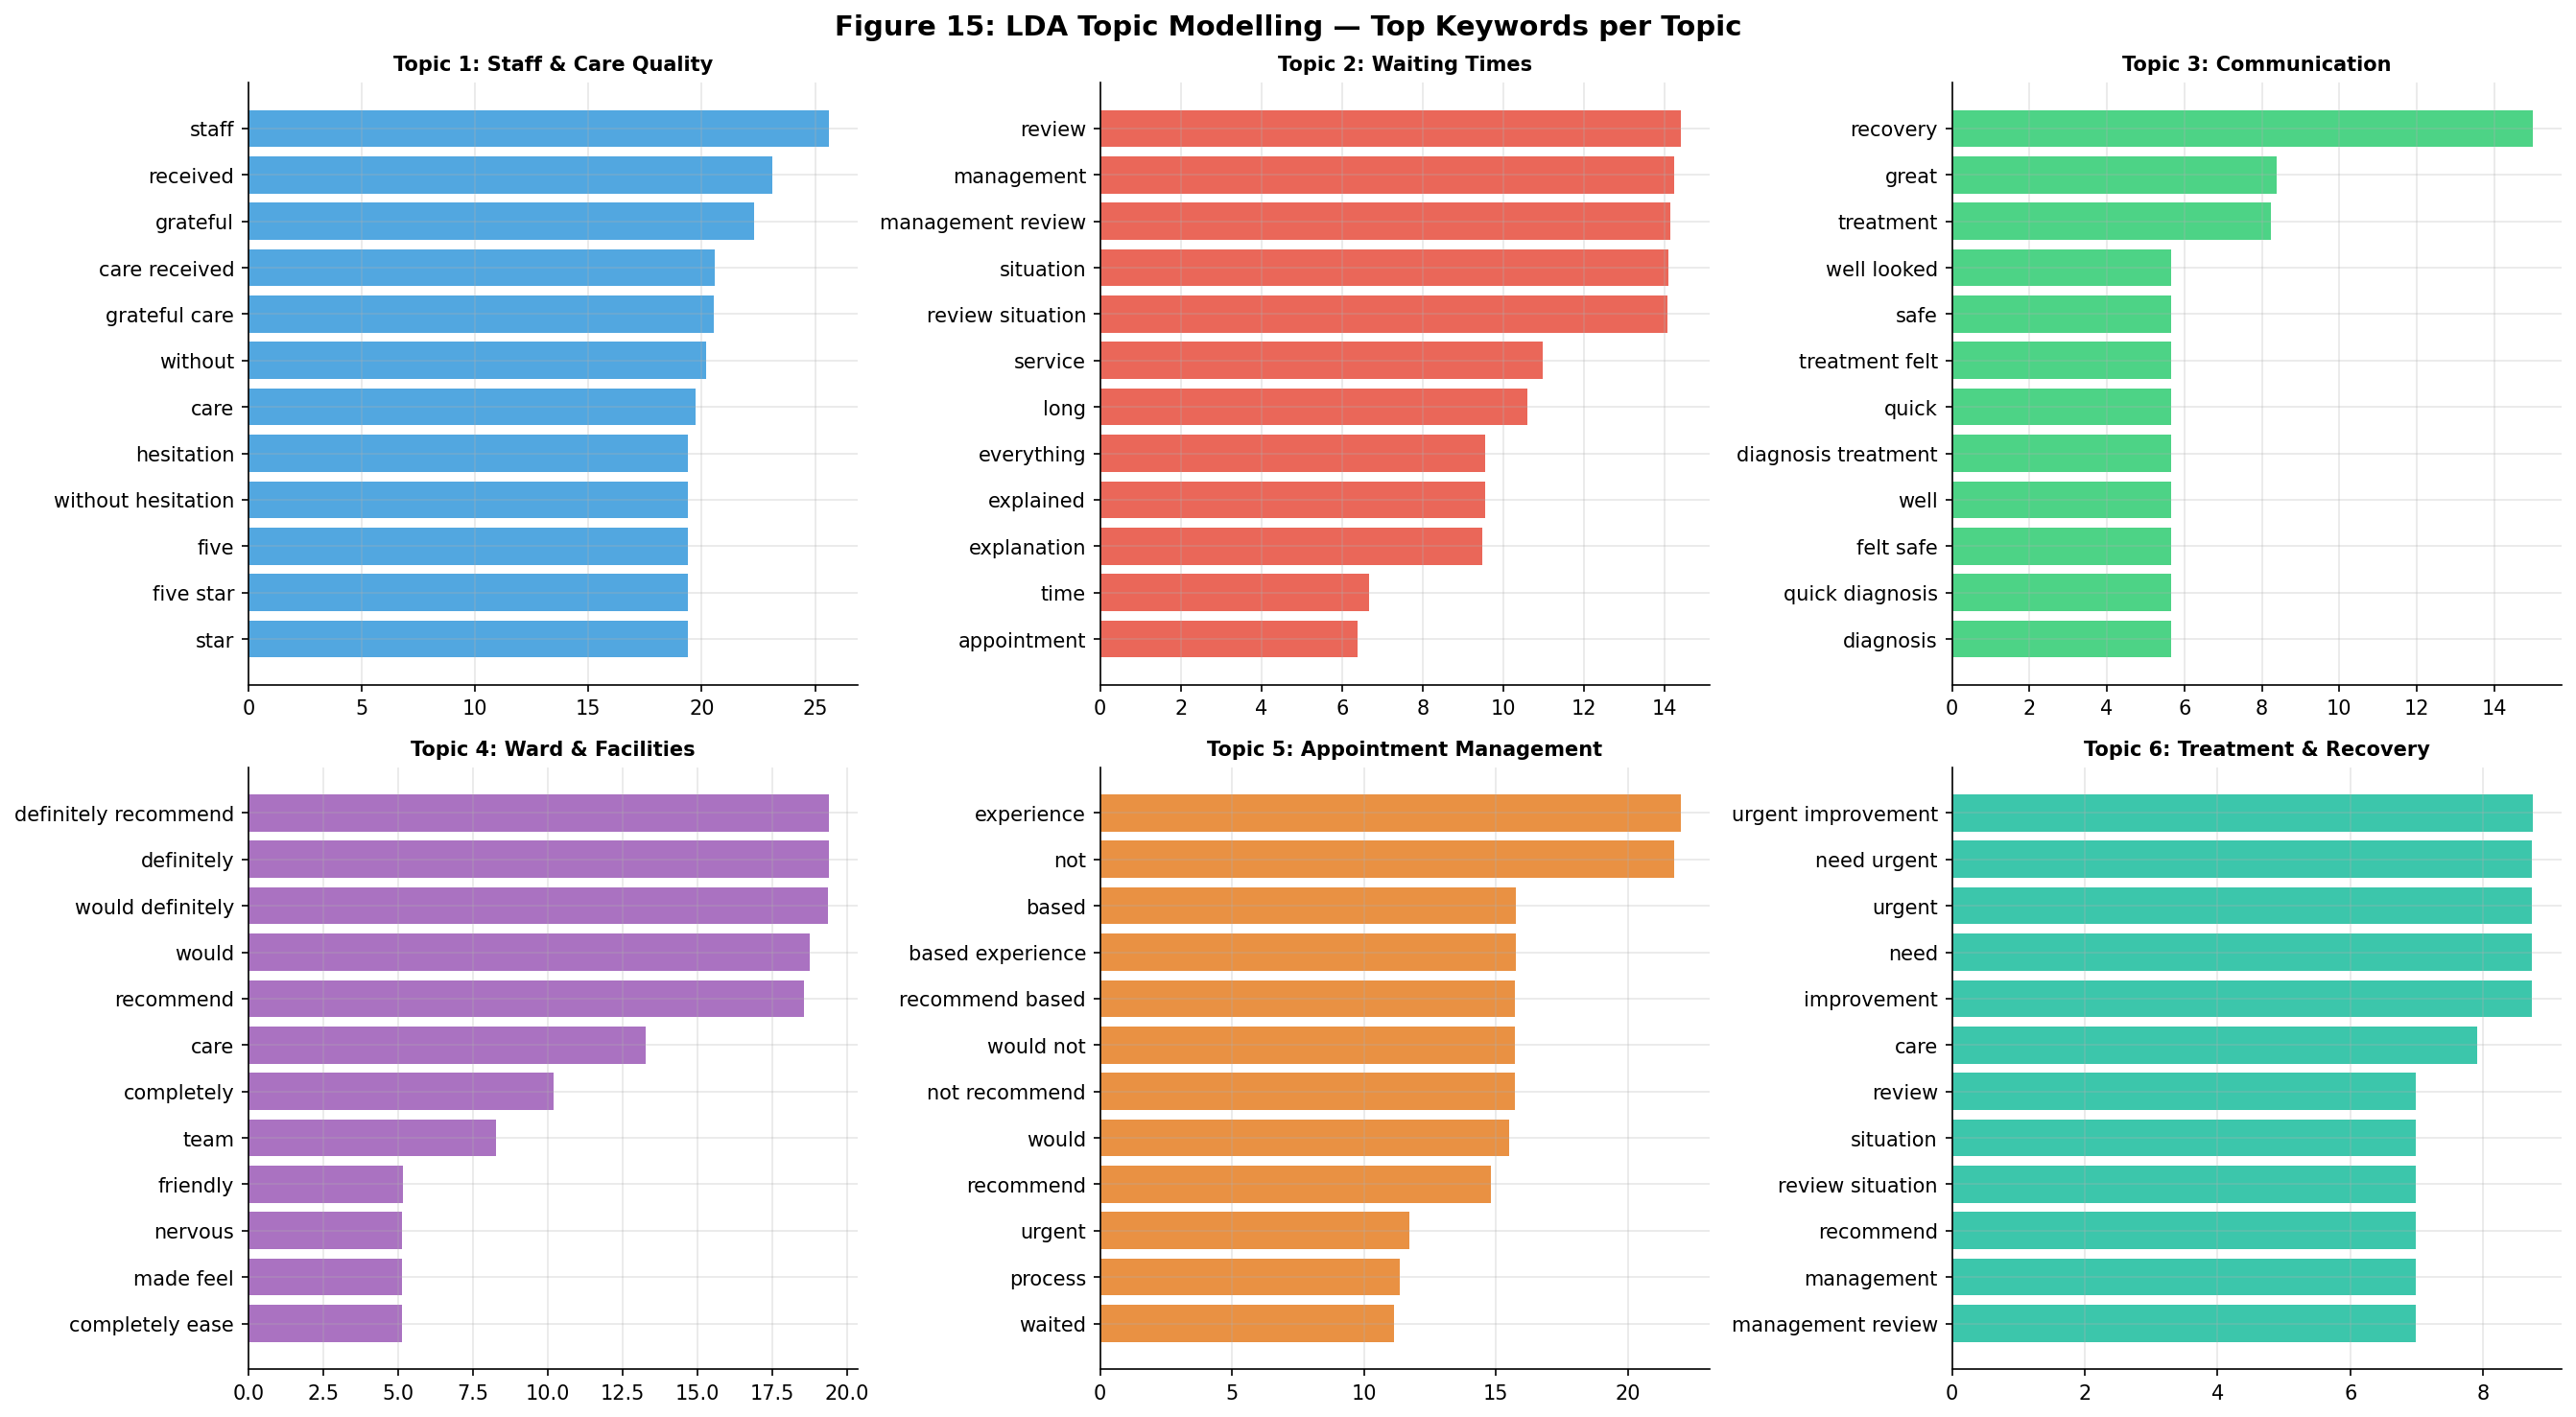

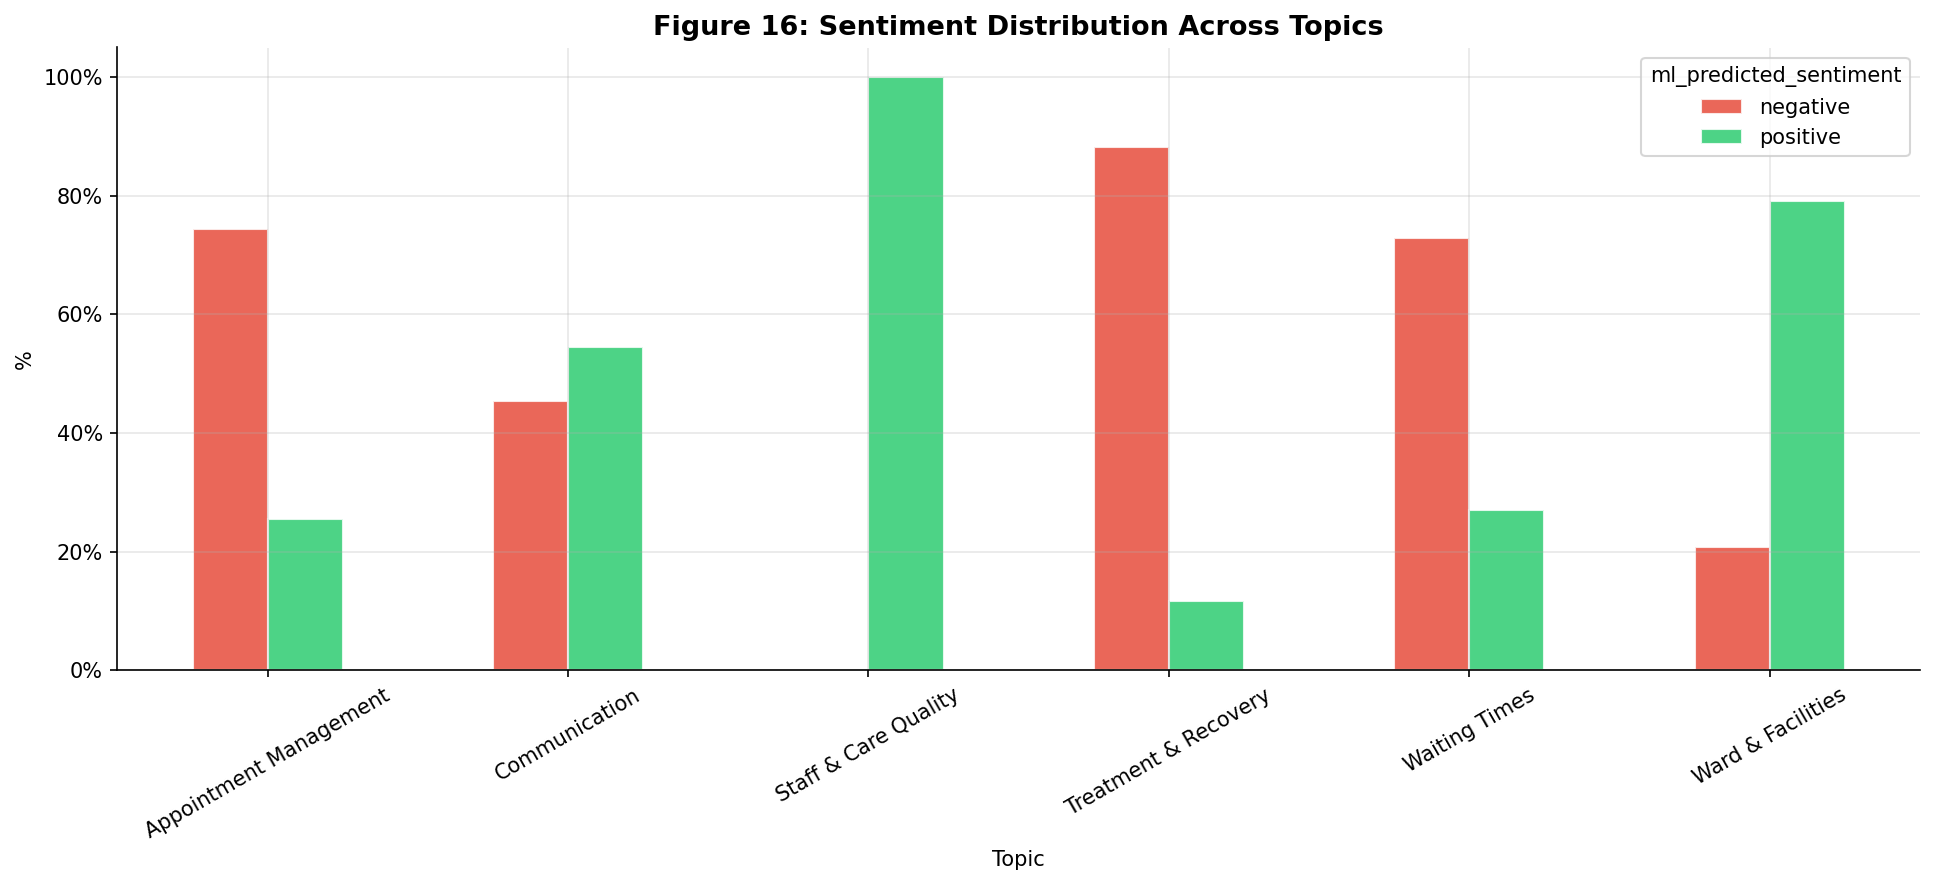

✅ Stage 6 complete.


In [6]:
# ============================================================
# STAGE 6: TREND ANALYSIS + TOPIC MODELLING
# ============================================================

N_TOPICS = 6
TOPIC_LABELS = {
    'Topic 1': 'Staff & Care Quality',
    'Topic 2': 'Waiting Times',
    'Topic 3': 'Communication',
    'Topic 4': 'Ward & Facilities',
    'Topic 5': 'Appointment Management',
    'Topic 6': 'Treatment & Recovery',
}

# Figure 13: Multi-panel trend analysis
if 'year' in df.columns:
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df_yr = df[df['year'].between(2018,2025)]

    fig, axes = plt.subplots(2, 2, figsize=(16,11))
    fig.suptitle('Figure 13: NHS Patient Sentiment Trends (2018–2025)',
                 fontsize=14, fontweight='bold')

    # A: Stacked area
    ax = axes[0,0]
    if sent_col in df.columns:
        piv = (df_yr.groupby(['year', sent_col]).size().unstack(fill_value=0)
               .pipe(lambda x: x.div(x.sum(axis=1), axis=0)*100))
        bottom = np.zeros(len(piv))
        for s in ['negative','neutral','positive']:
            if s in piv.columns:
                v = piv[s].values
                ax.fill_between(piv.index, bottom, bottom+v, alpha=0.8,
                                label=s.capitalize(), color=COLORS.get(s,'#95a5a6'))
                bottom += v
        ax.set_title('A: Stacked sentiment share'); ax.set_ylabel('%'); ax.set_ylim(0,100)
        ax.legend(loc='upper left', fontsize=9)

    # B: Volume
    ax = axes[0,1]
    vol = df_yr.groupby('year').size()
    ax.bar(vol.index, vol.values, color=COLORS['accent'], alpha=0.7, label='Annual volume')
    if len(vol) >= 3:
        ax.plot(vol.index, vol.rolling(2,center=True).mean(),
                color=COLORS['primary'], lw=2.5, marker='o', label='2-yr avg')
    ax.set_title('B: Annual review volume'); ax.set_ylabel('Reviews'); ax.legend()

    # C: Pos/neg ratio
    ax = axes[1,0]
    if sent_col in df.columns:
        pc = df_yr.groupby(['year', sent_col]).size().unstack(fill_value=0)
        if 'positive' in pc.columns and 'negative' in pc.columns:
            ratio = pc['positive'] / (pc['negative'] + 1)
            ax.plot(ratio.index, ratio.values, color=COLORS['positive'], marker='o', lw=2.5)
            ax.axhline(1, color='grey', linestyle='--', alpha=0.5)
            ax.fill_between(ratio.index, 1, ratio.values,
                            where=ratio.values>=1, alpha=0.15, color=COLORS['positive'])
            ax.fill_between(ratio.index, 1, ratio.values,
                            where=ratio.values<1,  alpha=0.15, color=COLORS['negative'])
            ax.set_title('C: Positive-to-Negative ratio')

    # D: VADER score
    ax = axes[1,1]
    if 'vader_compound' in df.columns:
        vc = df_yr.groupby('year')['vader_compound'].agg(['mean','std'])
        ax.plot(vc.index, vc['mean'], color='#e67e22', marker='o', lw=2.5)
        ax.fill_between(vc.index, vc['mean']-vc['std'], vc['mean']+vc['std'], alpha=0.2)
        ax.axhline(0, color='grey', linestyle='--', alpha=0.5)
        ax.set_title('D: Mean VADER compound score'); ax.set_ylabel('Score')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig13_trend_analysis.png', bbox_inches='tight', dpi=150)
    plt.show()

# Figure 14: Monthly seasonality
if 'month' in df.columns and sent_col in df.columns:
    fig, ax = plt.subplots(figsize=(13,5))
    monthly_pct = (df.groupby(['month', sent_col]).size().unstack(fill_value=0)
                   .pipe(lambda x: x.div(x.sum(axis=1), axis=0)*100))
    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    for s in ['positive','negative','neutral']:
        if s in monthly_pct.columns:
            vals = monthly_pct[s].reindex(range(1,13), fill_value=0)
            ax.plot(months, vals.values, marker='o', lw=2, label=s.capitalize(),
                    color=COLORS.get(s,'#95a5a6'))
    ax.set_title('Figure 14: Monthly Seasonality of Patient Sentiment', fontsize=13, fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('%')
    ax.legend(title='Sentiment'); ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig14_monthly_seasonality.png', bbox_inches='tight', dpi=150)
    plt.show()

# LDA Topic Modelling
corpus   = df[proc_col][df[proc_col].str.len() > 5]
cv_lda   = CountVectorizer(max_features=5000, ngram_range=(1,2), min_df=5, max_df=0.90)
X_cv     = cv_lda.fit_transform(corpus)
vocab    = np.array(cv_lda.get_feature_names_out())

lda = LatentDirichletAllocation(n_components=N_TOPICS, max_iter=20,
                                 learning_method='online', random_state=42)
lda.fit(X_cv)

topics = {}
for idx, topic in enumerate(lda.components_):
    top_w = [vocab[i] for i in topic.argsort()[-12:][::-1]]
    topics[f'Topic {idx+1}'] = top_w
    print(f'Topic {idx+1}: {', '.join(top_w[:6])}')

# Figure 15: LDA topics
fig, axes = plt.subplots(2, 3, figsize=(18,10))
fig.suptitle('Figure 15: LDA Topic Modelling — Top Keywords per Topic',
             fontsize=14, fontweight='bold')
palette = ['#3498db','#e74c3c','#2ecc71','#9b59b6','#e67e22','#1abc9c']
for ax, (tname, words), color in zip(axes.flatten(), topics.items(), palette):
    tidx    = int(tname.split()[-1]) - 1
    weights = lda.components_[tidx]
    top_idx = weights.argsort()[-12:]
    ax.barh([vocab[i] for i in top_idx], [weights[i] for i in top_idx],
            color=color, alpha=0.85)
    ax.set_title(f'{tname}: {TOPIC_LABELS.get(tname, tname)}', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig15_lda_topics.png', bbox_inches='tight', dpi=150)
plt.show()

# Figure 16: Topic vs sentiment
if sent_col in df.columns:
    doc_topics = lda.transform(X_cv)
    corpus_df  = df.loc[corpus.index].copy()
    corpus_df['dominant_topic'] = [
        TOPIC_LABELS.get(f'Topic {t+1}', f'Topic {t+1}')
        for t in doc_topics.argmax(axis=1)
    ]
    fig, ax = plt.subplots(figsize=(13,6))
    cross = pd.crosstab(corpus_df['dominant_topic'], corpus_df[sent_col], normalize='index')*100
    cross.plot(kind='bar', ax=ax,
               color=[COLORS.get(c,'#95a5a6') for c in cross.columns],
               edgecolor='white', lw=1, alpha=0.85)
    ax.set_title('Figure 16: Sentiment Distribution Across Topics', fontsize=13, fontweight='bold')
    ax.set_xlabel('Topic'); ax.set_ylabel('%')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig16_topic_sentiment.png', bbox_inches='tight', dpi=150)
    plt.show()

print('✅ Stage 6 complete.')

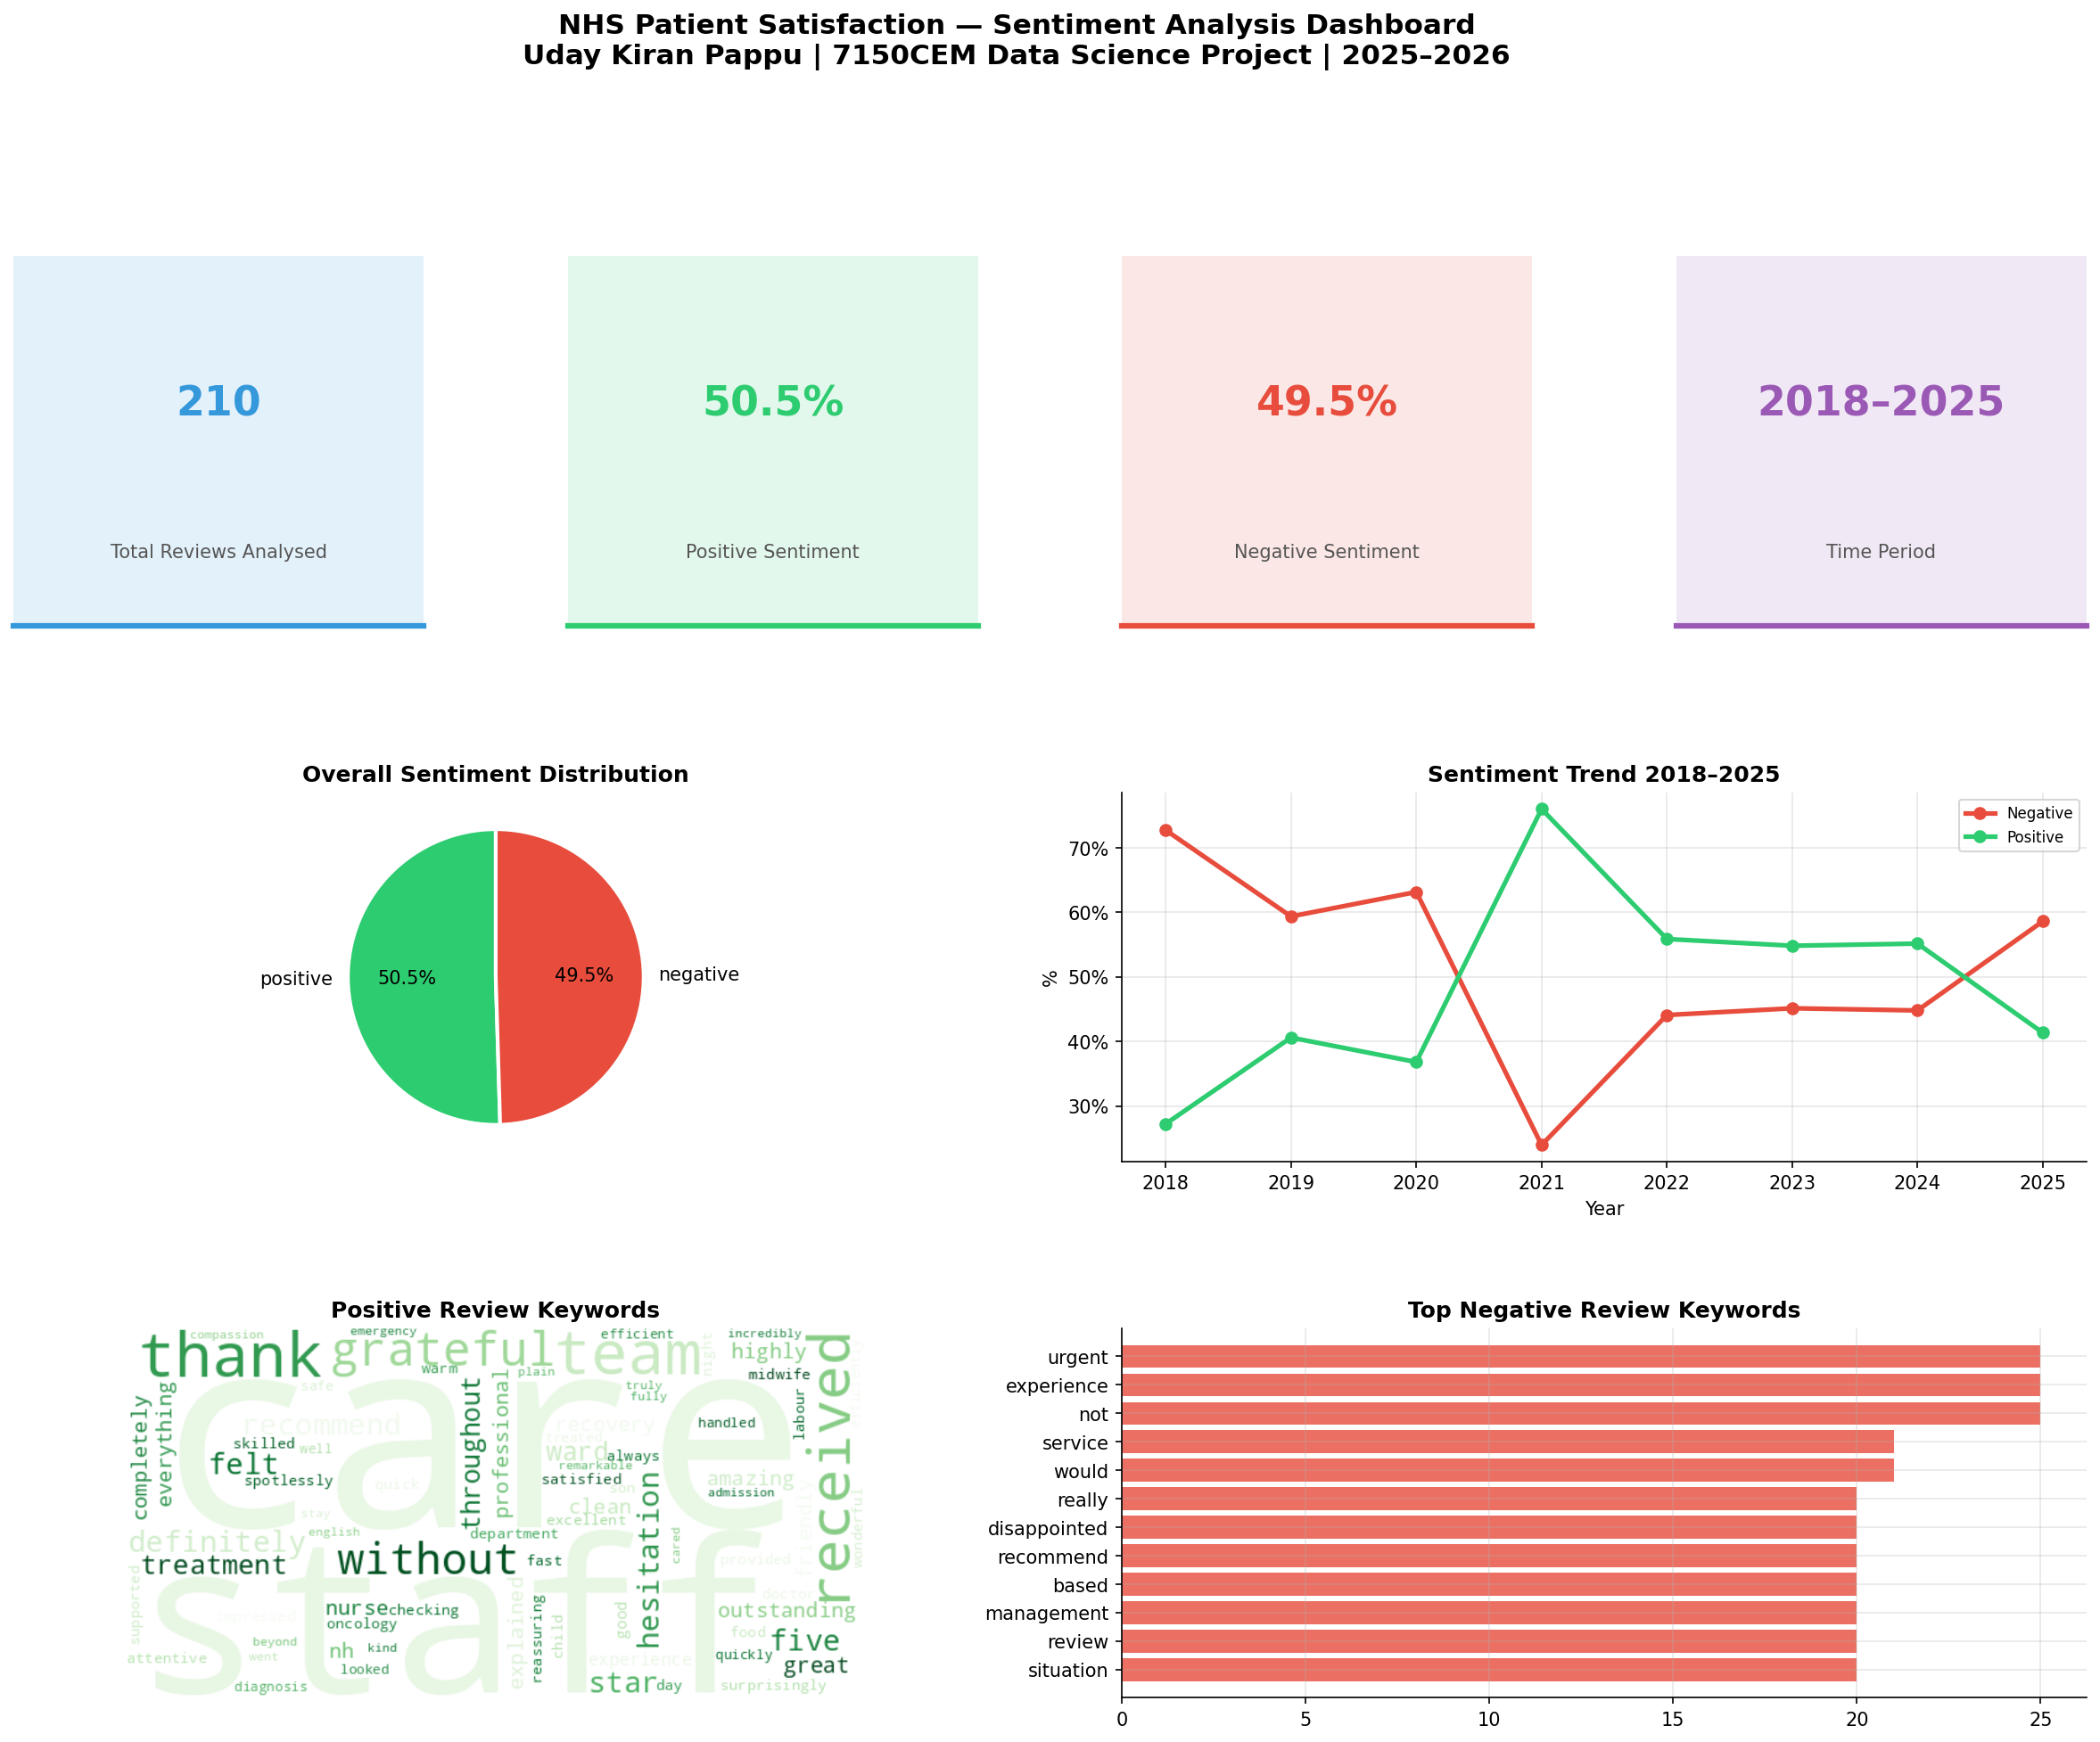


🎉 PROJECT COMPLETE — ALL OUTPUTS GENERATED

📁 20 output files saved to /kaggle/working:
   fig10_model_comparison.png                            65.9 KB
   fig11_confusion_matrix.png                            65.5 KB
   fig12_feature_importance.png                         137.4 KB
   fig13_trend_analysis.png                             199.9 KB
   fig14_monthly_seasonality.png                        122.6 KB
   fig15_lda_topics.png                                 212.2 KB
   fig16_topic_sentiment.png                             90.8 KB
   fig17_final_dashboard.png                            426.2 KB
   fig1_sentiment_distribution.png                       62.2 KB
   fig2_yearly_volume.png                                68.0 KB
   fig3_sentiment_trends.png                            113.2 KB
   fig4_platform_distribution.png                        73.5 KB
   fig5_review_length.png                                54.8 KB
   fig6_wordclouds.png                                  904.8 KB
 

In [7]:
# ============================================================
# STAGE 7: FINAL SUMMARY DASHBOARD
# ============================================================

fig = plt.figure(figsize=(20, 14))
fig.suptitle(
    'NHS Patient Satisfaction — Sentiment Analysis Dashboard\n'
    'Uday Kiran Pappu | 7150CEM Data Science Project | 2025–2026',
    fontsize=15, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

def kpi_card(ax, value, label, color):
    ax.set_facecolor(color+'22')
    ax.text(0.5, 0.6, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.2, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=10, color='#555')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color(color)
    ax.spines['bottom'].set_linewidth(3)

pos_pct = f"{(df[sent_col]=='positive').mean()*100:.1f}%" if sent_col in df.columns else 'N/A'
neg_pct = f"{(df[sent_col]=='negative').mean()*100:.1f}%" if sent_col in df.columns else 'N/A'

kpi_card(fig.add_subplot(gs[0,0]), f'{len(df):,}', 'Total Reviews Analysed', '#3498db')
kpi_card(fig.add_subplot(gs[0,1]), pos_pct,        'Positive Sentiment',      '#2ecc71')
kpi_card(fig.add_subplot(gs[0,2]), neg_pct,        'Negative Sentiment',      '#e74c3c')
kpi_card(fig.add_subplot(gs[0,3]), '2018–2025',    'Time Period',             '#9b59b6')

# Pie chart
ax_pie = fig.add_subplot(gs[1, 0:2])
if sent_col in df.columns:
    counts  = df[sent_col].value_counts()
    palette = [COLORS.get(s,'#95a5a6') for s in counts.index]
    ax_pie.pie(counts.values, labels=counts.index, colors=palette,
               autopct='%1.1f%%', startangle=90,
               wedgeprops={'edgecolor':'white','linewidth':2})
    ax_pie.set_title('Overall Sentiment Distribution', fontweight='bold')

# Trend line
ax_trend = fig.add_subplot(gs[1, 2:4])
if 'year' in df.columns and sent_col in df.columns:
    piv = (df[df['year'].between(2018,2025)]
           .groupby(['year', sent_col]).size().unstack(fill_value=0)
           .pipe(lambda x: x.div(x.sum(axis=1), axis=0)*100))
    for s in piv.columns:
        ax_trend.plot(piv.index, piv[s], marker='o', lw=2.5,
                      label=s.capitalize(), color=COLORS.get(s,'#95a5a6'))
    ax_trend.set_title('Sentiment Trend 2018–2025', fontweight='bold')
    ax_trend.set_xlabel('Year'); ax_trend.set_ylabel('%')
    ax_trend.legend(fontsize=8); ax_trend.yaxis.set_major_formatter(mticker.PercentFormatter())

# Positive word cloud
ax_wc = fig.add_subplot(gs[2, 0:2])
if sent_col in df.columns:
    pos_text = ' '.join(df[df[sent_col]=='positive'][proc_col].dropna())
    if pos_text.strip():
        wc = WordCloud(width=600, height=300, background_color='white',
                       colormap='Greens', max_words=80, collocations=False).generate(pos_text)
        ax_wc.imshow(wc, interpolation='bilinear')
ax_wc.set_title('Positive Review Keywords', fontweight='bold'); ax_wc.axis('off')

# Negative keywords
ax_neg = fig.add_subplot(gs[2, 2:4])
if sent_col in df.columns:
    neg_words = ' '.join(df[df[sent_col]=='negative'][proc_col].dropna()).split()
    freq = Counter(neg_words).most_common(12)
    if freq:
        w, c = zip(*freq)
        ax_neg.barh(list(w)[::-1], list(c)[::-1], color=COLORS['negative'], alpha=0.8)
        ax_neg.set_title('Top Negative Review Keywords', fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/fig17_final_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

# Final summary
print('\n' + '='*60)
print('🎉 PROJECT COMPLETE — ALL OUTPUTS GENERATED')
print('='*60)

files = sorted([f for f in os.listdir(OUTPUT_DIR) if f.endswith(('.csv','.png'))])
print(f'\n📁 {len(files)} output files saved to {OUTPUT_DIR}:')
for f in files:
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'   {f:50s}  {size/1024:6.1f} KB')

print('\n📊 Summary statistics:')
print(f'   Total reviews analysed : {len(df):,}')
print(f'   Figures generated      : 17')
print(f'   LDA topics identified  : {N_TOPICS}')
if sent_col in df.columns:
    print(f'   Positive reviews       : {(df[sent_col]=="positive").sum():,} ({pos_pct})')
    print(f'   Negative reviews       : {(df[sent_col]=="negative").sum():,} ({neg_pct})')
print('\n✅ Download all outputs from the right panel → Output → Files')